# 🏈 NFL Big Data Bowl 2027
## From Combine Movement to NFL Career Success

### Research Question

Can 10 Hz sensor-based movement features captured during the NFL Scouting Combine
reveal information about future NFL player success that is not captured by
traditional Combine measurements?

### Core Idea

We compare three sources of information:

1. Traditional Combine measurements
2. Sensor-derived movement characteristics
3. Traditional + sensor-derived features

The goal is to determine whether detailed movement patterns provide additional
signal for identifying future NFL success.

### Data Used

This analysis intentionally uses four competition datasets:

- `combine_tracking.csv`
- `combine_results.csv`
- `players.csv`
- `player_career_successes.csv`

The analysis is designed as a single reproducible notebook.

In [1]:
# Core
import os
import gc
import warnings

import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt

# Statistics
from scipy import stats

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("Environment ready.")

Environment ready.


In [3]:
required_files = [
    "combine_tracking.csv",
    "combine_results.csv",
    "players.csv",
    "player_career_successes.csv"
]

print("Checking required files...\n")

missing = []

for file in required_files:
    if os.path.exists(file):
        size_mb = os.path.getsize(file) / (1024 ** 2)
        print(f"✓ {file:<32} {size_mb:8.2f} MB")
    else:
        print(f"✗ {file:<32} MISSING")
        missing.append(file)

if missing:
    print("\nMissing files:", missing)
else:
    print("\n✓ All four datasets are available.")

Checking required files...

✓ combine_tracking.csv                36.00 MB
✓ combine_results.csv                  0.04 MB
✓ players.csv                          0.05 MB
✓ player_career_successes.csv          0.01 MB

✓ All four datasets are available.


In [4]:
combine_results = pd.read_csv("combine_results.csv")
players = pd.read_csv("players.csv")
career_successes = pd.read_csv("player_career_successes.csv")

print("combine_results:", combine_results.shape)
print("players:", players.shape)
print("career_successes:", career_successes.shape)

combine_results: (510, 18)
players: (510, 10)
career_successes: (510, 9)


In [5]:
print("=" * 80)
print("COMBINE RESULTS")
print("=" * 80)

display(combine_results.head())
print("\nColumns:")
print(combine_results.columns.tolist())


print("\n" + "=" * 80)
print("PLAYERS")
print("=" * 80)

display(players.head())
print("\nColumns:")
print(players.columns.tolist())


print("\n" + "=" * 80)
print("CAREER SUCCESSES")
print("=" * 80)

display(career_successes.head())
print("\nColumns:")
print(career_successes.columns.tolist())

COMBINE RESULTS


,draft_year,nfl_id,combine_position,combine_height,combine_weight,hand_size,arm_length,wing_span,ten_yd_split,forty,vertical,broad_jump,three_cone,short_shuttle,bench_reps,ngs_athleticism_score,ngs_college_production_score,ngs_final_score
0,2023,56040,TE,77.875,245,10.000,32.250,79.750,1.60,4.84,38.5,125.0,NaN,NaN,NaN,60,NaN,NaN
1,2023,56010,DB,70.625,191,8.750,29.625,72.250,1.58,4.59,33.5,116.0,NaN,NaN,23.0,60,77.0,74.0
2,2023,56085,TE,79.375,255,10.250,34.000,83.125,1.57,4.55,40.0,128.0,6.87,4.12,23.0,97,65.0,79.0
3,2023,56056,WR,72.250,192,9.625,31.875,76.125,1.51,4.33,NaN,NaN,NaN,NaN,NaN,76,68.0,73.0
4,2023,56118,WR,71.625,191,9.500,31.000,75.000,1.52,4.54,38.5,120.0,6.98,4.15,14.0,65,65.0,64.0



Columns:
['draft_year', 'nfl_id', 'combine_position', 'combine_height', 'combine_weight', 'hand_size', 'arm_length', 'wing_span', 'ten_yd_split', 'forty', 'vertical', 'broad_jump', 'three_cone', 'short_shuttle', 'bench_reps', 'ngs_athleticism_score', 'ngs_college_production_score', 'ngs_final_score']

PLAYERS


,nfl_id,display_name,draft_year,nfl_position,birth_date,college_name,college_conference,draft_round,draft_pick_within_round,draft_overall_pick
0,55867,Will Anderson,2023,DE,2001-09-02,Alabama,Southeastern Conference,1.0,3.0,3.0
1,55870,Paris Johnson,2023,T,2001-07-31,Ohio State,Big Ten Conference,1.0,6.0,6.0
2,55874,Darnell Wright,2023,T,2001-08-10,Tennessee,Southeastern Conference,1.0,10.0,10.0
3,55875,Peter Skoronski,2023,G,2001-07-31,Northwestern,Big Ten Conference,1.0,11.0,11.0
4,55877,Lukas Van Ness,2023,DE,2001-07-06,Iowa,Big Ten Conference,1.0,13.0,13.0



Columns:
['nfl_id', 'display_name', 'draft_year', 'nfl_position', 'birth_date', 'college_name', 'college_conference', 'draft_round', 'draft_pick_within_round', 'draft_overall_pick']

CAREER SUCCESSES


,nfl_id,career_offensive_snaps,career_defensive_snaps,career_special_teams_snaps,career_games_active,career_games_started,ap_all_pro_1st_team,ap_all_pro_2nd_team,pro_bowl_original_ballot
0,55867,0,1884,92,51,44,1,0,1
1,55870,2802,0,169,47,43,0,0,0
2,55874,3222,0,167,51,49,0,1,0
3,55875,3011,0,170,51,48,0,0,0
4,55877,0,1056,387,51,2,0,0,0



Columns:
['nfl_id', 'career_offensive_snaps', 'career_defensive_snaps', 'career_special_teams_snaps', 'career_games_active', 'career_games_started', 'ap_all_pro_1st_team', 'ap_all_pro_2nd_team', 'pro_bowl_original_ballot']


In [6]:
combine_tracking = pd.read_csv("combine_tracking.csv")

print("Shape:", combine_tracking.shape)
print("\nMemory usage:")
print(f"{combine_tracking.memory_usage(deep=True).sum() / (1024**2):.2f} MB")

display(combine_tracking.head())

Shape: (463189, 14)

Memory usage:
181.99 MB


,draft_year,event_id,nfl_id,entity_type,time,drill_type,drill_name,attempt,x,y,s,a,dis,dir
0,2025,20250302100900_1740941802777_000,58286,PLAYER,2025-03-02T18:56:38.200,SKILL_DRILLS_OL,OL_PULL_DRILL_FOLD_BLOCK_RIGHT,4,44.785924,28.285528,0.220828,0.682443,0.011085,250.278576
1,2025,20250302100900_1740941802777_000,58286,PLAYER,2025-03-02T18:56:38.300,SKILL_DRILLS_OL,OL_PULL_DRILL_FOLD_BLOCK_RIGHT,4,44.723780,28.297391,0.332931,0.619551,0.003864,257.319206
2,2025,20250302100900_1740941802777_000,58286,PLAYER,2025-03-02T18:56:38.400,SKILL_DRILLS_OL,OL_PULL_DRILL_FOLD_BLOCK_RIGHT,4,44.632680,28.279528,0.481838,0.596455,0.008305,253.176813
3,2025,20250302100900_1740941802777_000,58286,PLAYER,2025-03-02T18:56:38.500,SKILL_DRILLS_OL,OL_PULL_DRILL_FOLD_BLOCK_RIGHT,4,44.544022,28.243767,0.599350,0.664436,0.007964,247.044153
4,2025,20250302100900_1740941802777_000,58286,PLAYER,2025-03-02T18:56:38.600,SKILL_DRILLS_OL,OL_PULL_DRILL_FOLD_BLOCK_RIGHT,4,44.471466,28.210294,0.657540,0.908250,0.005382,240.622668


In [7]:
combine_tracking = pd.read_csv("combine_tracking.csv")

print("Shape:", combine_tracking.shape)
print("\nMemory usage:")
print(f"{combine_tracking.memory_usage(deep=True).sum() / (1024**2):.2f} MB")

display(combine_tracking.head())

Shape: (463189, 14)

Memory usage:
181.99 MB


,draft_year,event_id,nfl_id,entity_type,time,drill_type,drill_name,attempt,x,y,s,a,dis,dir
0,2025,20250302100900_1740941802777_000,58286,PLAYER,2025-03-02T18:56:38.200,SKILL_DRILLS_OL,OL_PULL_DRILL_FOLD_BLOCK_RIGHT,4,44.785924,28.285528,0.220828,0.682443,0.011085,250.278576
1,2025,20250302100900_1740941802777_000,58286,PLAYER,2025-03-02T18:56:38.300,SKILL_DRILLS_OL,OL_PULL_DRILL_FOLD_BLOCK_RIGHT,4,44.723780,28.297391,0.332931,0.619551,0.003864,257.319206
2,2025,20250302100900_1740941802777_000,58286,PLAYER,2025-03-02T18:56:38.400,SKILL_DRILLS_OL,OL_PULL_DRILL_FOLD_BLOCK_RIGHT,4,44.632680,28.279528,0.481838,0.596455,0.008305,253.176813
3,2025,20250302100900_1740941802777_000,58286,PLAYER,2025-03-02T18:56:38.500,SKILL_DRILLS_OL,OL_PULL_DRILL_FOLD_BLOCK_RIGHT,4,44.544022,28.243767,0.599350,0.664436,0.007964,247.044153
4,2025,20250302100900_1740941802777_000,58286,PLAYER,2025-03-02T18:56:38.600,SKILL_DRILLS_OL,OL_PULL_DRILL_FOLD_BLOCK_RIGHT,4,44.471466,28.210294,0.657540,0.908250,0.005382,240.622668


In [8]:
def audit_dataframe(df, name):
    print("=" * 80)
    print(name)
    print("=" * 80)

    print(f"Rows: {len(df):,}")
    print(f"Columns: {len(df.columns):,}")
    print(f"Duplicate rows: {df.duplicated().sum():,}")

    missing = (
        df.isna()
        .sum()
        .sort_values(ascending=False)
    )

    missing_pct = (
        missing / len(df) * 100
    ).round(2)

    audit = pd.DataFrame({
        "missing": missing,
        "missing_%": missing_pct,
        "dtype": df.dtypes.astype(str)
    })

    display(audit[audit["missing"] > 0].head(30))


audit_dataframe(combine_results, "Combine Results")
audit_dataframe(players, "Players")
audit_dataframe(career_successes, "Career Successes")
audit_dataframe(combine_tracking, "Combine Tracking")

Combine Results
Rows: 510
Columns: 18
Duplicate rows: 0


,missing,missing_%,dtype
bench_reps,318,62.35,float64
broad_jump,87,17.06,float64
forty,86,16.86,float64
ngs_college_production_score,1,0.20,float64
ngs_final_score,1,0.20,float64
short_shuttle,309,60.59,float64
ten_yd_split,85,16.67,float64
three_cone,330,64.71,float64
vertical,72,14.12,float64


Players
Rows: 510
Columns: 10
Duplicate rows: 0


,missing,missing_%,dtype
draft_overall_pick,127,24.9,float64
draft_pick_within_round,127,24.9,float64
draft_round,127,24.9,float64


Career Successes
Rows: 510
Columns: 9
Duplicate rows: 0


,missing,missing_%,dtype


Combine Tracking
Rows: 463,189
Columns: 14
Duplicate rows: 0


,missing,missing_%,dtype


In [9]:
datasets = {
    "combine_results": set(combine_results.columns),
    "players": set(players.columns),
    "career_successes": set(career_successes.columns),
    "combine_tracking": set(combine_tracking.columns)
}

print("Columns shared between datasets:\n")

names = list(datasets.keys())

for i in range(len(names)):
    for j in range(i + 1, len(names)):
        a = names[i]
        b = names[j]

        shared = datasets[a] & datasets[b]

        print(f"{a} ↔ {b}")
        print(sorted(shared))
        print()

Columns shared between datasets:

combine_results ↔ players
['draft_year', 'nfl_id']

combine_results ↔ career_successes
['nfl_id']

combine_results ↔ combine_tracking
['draft_year', 'nfl_id']

players ↔ career_successes
['nfl_id']

players ↔ combine_tracking
['draft_year', 'nfl_id']

career_successes ↔ combine_tracking
['nfl_id']



In [10]:
print("Combine Results — numeric variables")
display(combine_results.describe(include="all").T)

print("\nCareer Successes — numeric variables")
display(career_successes.describe(include="all").T)

Combine Results — numeric variables


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
draft_year,510.0,NaN,NaN,NaN,2024.02549,0.808439,2023.0,2023.0,2024.0,2025.0,2025.0
nfl_id,510.0,NaN,NaN,NaN,57331.319608,979.506689,55867.0,56273.5,57290.0,58302.75,59278.0
combine_position,510,5,DB,122,NaN,NaN,NaN,NaN,NaN,NaN,NaN
combine_height,510.0,NaN,NaN,NaN,74.579657,2.628102,68.125,72.625,75.0,76.5,80.625
combine_weight,510.0,NaN,NaN,NaN,248.380392,53.254702,154.0,198.0,245.5,304.0,374.0
hand_size,510.0,NaN,NaN,NaN,9.571814,0.602178,8.0,9.125,9.5,10.0,11.625
arm_length,510.0,NaN,NaN,NaN,32.410784,1.419286,28.5,31.375,32.375,33.5,36.875
wing_span,510.0,NaN,NaN,NaN,78.465931,3.273243,69.0,76.25,78.5,80.84375,88.25
ten_yd_split,425.0,NaN,NaN,NaN,1.632,0.115573,1.46,1.54,1.59,1.74,1.96
forty,424.0,NaN,NaN,NaN,4.733514,0.309449,4.28,4.47,4.62,5.01,5.48



Career Successes — numeric variables


,count,mean,std,min,25%,50%,75%,max
nfl_id,510.0,57331.319608,979.506689,55867.0,56273.50,57290.0,58302.75,59278.0
career_offensive_snaps,510.0,327.415686,632.400084,0.0,0.00,0.0,361.75,3303.0
career_defensive_snaps,510.0,234.307843,492.121894,0.0,0.00,0.0,220.50,2666.0
career_special_teams_snaps,510.0,113.503922,156.194148,0.0,5.00,53.0,147.75,957.0
career_games_active,510.0,21.721569,16.285063,0.0,6.25,17.0,34.00,51.0
career_games_started,510.0,7.852941,11.466015,0.0,0.00,2.0,12.00,50.0
ap_all_pro_1st_team,510.0,0.011765,0.107931,0.0,0.00,0.0,0.00,1.0
ap_all_pro_2nd_team,510.0,0.003922,0.062561,0.0,0.00,0.0,0.00,1.0
pro_bowl_original_ballot,510.0,0.027451,0.196310,0.0,0.00,0.0,0.00,2.0


##  Understanding Combine Movement Data

The Combine tracking dataset records athlete movement at high temporal resolution
during drills and position-specific exercises.

Before engineering movement features, we examine:

- which drills are represented,
- how many players participate in each drill,
- how many attempts are recorded,
- and which positions are associated with each movement task.

This allows the analysis to remain grounded in the actual structure of the data.

In [11]:
drill_summary = (
    combine_tracking
    .groupby(["drill_type", "drill_name"])
    .agg(
        rows=("nfl_id", "size"),
        players=("nfl_id", "nunique"),
        attempts=("attempt", "nunique")
    )
    .sort_values("players", ascending=False)
)

display(drill_summary)

rows  players  \
drill_type       drill_name                                                     
FORTY_YARD_DASH  FORTY_YARD_DASH                               41500      418   
SHORT_SHUTTLE    SHORT_SHUTTLE                                 11690      170   
THREE_CONE_DRILL THREE_CONE_DRILL                              15951      160   
SKILL_DRILLS_DB  BACK_PEDAL_AND_90_DEGREE_BREAK_TO_BALL         8422      122   
                 BOX_DRILL                                      9439      122   
                 BACK_PEDAL_AND_TRANSITION_45_DEGREE_REACTION  21569      122   
                 W_DRILL                                       10214      121   
SKILL_DRILLS_OL  FIVE_YARD_WAVE_DRILL_SLIDE_AND_SHUFFLE        18087      120   
                 PASS_RUSH_DROP                                10752      120   
SKILL_DRILLS_DB  GAUNTLET_DRILL                                12253      119   
SKILL_DRILLS_OL  OL_PULL_DRILL_FOLD_BLOCK_RIGHT                 4706      119   
                 SCREEN_DRILL                                   8031      119   
SKILL_DRILLS_DL  PASS_RUSH_DRILL                                9847      114   
                 FOUR_BAG_AGILITY_DRILL                        11709      112   
                 FRONT_START_WAVE_DRILL_AND_LATERAL_REACTION   12845      112   
                 RUN_AND_CLUB_DRILL                             8180      112   
SKILL_DRILLS_DB  TERYL_AUSTIN_DRILL_2                           9514      111   
SKILL_DRILLS_DL  BODY_CONTROL_DRILL                             6611      111   
                 RUN_THE_HOOP_DRILL                             9120      109   
SKILL_DRILLS_WR  DAGGER_ROUTE_LEFT                              9917      107   
                 SLANT_ROUTE_LEFT                               5320      107   
                 GAUNTLET_DRILL                                18265      107   
                 CURL_ROUTE_RIGHT                               7993      103   
SKILL_DRILLS_DB  TERYL_AUSTIN_DRILL_1                           7765      101   
SKILL_DRILLS_WR  SLOT_STRIKE_ROUTE_LEFT                         8457      101   
                 OVER_SHOULDER_ADJUST                           8703      100   
                 SLOT_SAIL_ROUTE_RIGHT                          9524       98   
                 GO_ROUTE_RIGHT                                 9843       98   
SKILL_DRILLS_OL  OL_PULL_DRILL_DEEP_SHORT_PULL_LEFT             4412       98   
SKILL_DRILLS_WR  RED_ZONE_FADE_RIGHT                            6256       98   
                 COMEBACK_ROUTE_RIGHT                           9266       98   
                 POST_CORNER_ROUTE_RIGHT                       10517       96   
SKILL_DRILLS_OL  OL_PULL_DRILL_LONG_PULL_RIGHT                  4720       93   
SKILL_DRILLS_DB  LINE_DRILL                                    11895       85   
SKILL_DRILLS_OL  PASS_PRO-MIRROR_DRILL                          7020       84   
SKILL_DRILLS_WR  SPEED_OUT_ROUTE_LEFT                           5619       76   
                 POST_CORNER_ROUTE_LEFT                         4289       70   
SKILL_DRILLS_DL  BACK_PEDAL_AND_REACT                           6057       55   
SKILL_DRILLS_TE  FLAT_ROUTE_LEFT                                3066       42   
                 HOOK_ROUTE_RIGHT                               3986       41   
                 GAUNTLET_DRILL                                 7710       41   
                 IN_ROUTE_LEFT                                  3842       40   
                 WHEEL_ROUTE_LEFT                               3323       40   
                 BLOCK_EXPLOSION                                2330       39   
SKILL_DRILLS_WR  CIRCUS_ROUTE_LEFT                              4739       37   
SKILL_DRILLS_OL  PASS_PRO_MIRROR_DRILL                          3401       37   
SKILL_DRILLS_DL  SHORT_ZONE_BREAKS                              7895       36   
SKILL_DRILLS_DB  LINE                                           3552       33   
SKILL_DRILLS_W

In [12]:
tracking_players = combine_tracking["nfl_id"].nunique()

print(f"Players in tracking data: {tracking_players}")
print(f"Players in Combine results: {combine_results['nfl_id'].nunique()}")
print(f"Players in career data: {career_successes['nfl_id'].nunique()}")

coverage = pd.DataFrame({
    "Dataset": [
        "Combine Results",
        "Tracking",
        "Career Success"
    ],
    "Unique Players": [
        combine_results["nfl_id"].nunique(),
        tracking_players,
        career_successes["nfl_id"].nunique()
    ]
})

display(coverage)

Players in tracking data: 510
Players in Combine results: 510
Players in career data: 510


,Dataset,Unique Players
0,Combine Results,510
1,Tracking,510
2,Career Success,510


In [13]:
master = (
    combine_results
    .merge(
        players,
        on=["nfl_id", "draft_year"],
        how="left",
        suffixes=("", "_player")
    )
    .merge(
        career_successes,
        on="nfl_id",
        how="left"
    )
)

print("Master table:", master.shape)

display(master.head())

Master table: (510, 34)


,draft_year,nfl_id,combine_position,combine_height,combine_weight,hand_size,arm_length,wing_span,ten_yd_split,forty,vertical,broad_jump,three_cone,short_shuttle,bench_reps,ngs_athleticism_score,ngs_college_production_score,ngs_final_score,display_name,nfl_position,birth_date,college_name,college_conference,draft_round,draft_pick_within_round,draft_overall_pick,career_offensive_snaps,career_defensive_snaps,career_special_teams_snaps,career_games_active,career_games_started,ap_all_pro_1st_team,ap_all_pro_2nd_team,pro_bowl_original_ballot
0,2023,56040,TE,77.875,245,10.000,32.250,79.750,1.60,4.84,38.5,125.0,NaN,NaN,NaN,60,NaN,NaN,Davis Allen,TE,2001-02-03,Clemson,Atlantic Coast Conference,5.0,41.0,175.0,1085,0,431,51,11,0,0,0
1,2023,56010,DB,70.625,191,8.750,29.625,72.250,1.58,4.59,33.5,116.0,NaN,NaN,23.0,60,77.0,74.0,Jammie Robinson,SS,2001-01-24,Florida State,Atlantic Coast Conference,5.0,11.0,145.0,0,75,487,41,2,0,0,0
2,2023,56085,TE,79.375,255,10.250,34.000,83.125,1.57,4.55,40.0,128.0,6.87,4.12,23.0,97,65.0,79.0,Zack Kuntz,TE,1999-06-04,Old Dominion,Conference USA,7.0,3.0,220.0,3,0,10,3,0,0,0,0
3,2023,56056,WR,72.250,192,9.625,31.875,76.125,1.51,4.33,NaN,NaN,NaN,NaN,NaN,76,68.0,73.0,Trey Palmer,WR,2001-04-02,Nebraska,Big Ten Conference,6.0,14.0,191.0,1022,0,60,38,11,0,0,0
4,2023,56118,WR,71.625,191,9.500,31.000,75.000,1.52,4.54,38.5,120.0,6.98,4.15,14.0,65,65.0,64.0,Ronnie Bell,WR,2000-01-28,Michigan,Big Ten Conference,7.0,36.0,253.0,334,0,135,30,0,0,0,0


In [14]:
print("Rows:", len(master))
print("Unique players:", master["nfl_id"].nunique())

assert len(master) == master["nfl_id"].nunique()

print("✓ One row per player.")

Rows: 510
Unique players: 510
✓ One row per player.


In [15]:
master["career_total_snaps"] = (
    master["career_offensive_snaps"].fillna(0)
    + master["career_defensive_snaps"].fillna(0)
    + master["career_special_teams_snaps"].fillna(0)
)

master["career_total_awards"] = (
    master["ap_all_pro_1st_team"].fillna(0)
    + master["ap_all_pro_2nd_team"].fillna(0)
    + master["pro_bowl_original_ballot"].fillna(0)
)

display(
    master[
        [
            "display_name",
            "career_total_snaps",
            "career_games_active",
            "career_games_started",
            "career_total_awards"
        ]
    ].head(10)
)

,display_name,career_total_snaps,career_games_active,career_games_started,career_total_awards
0,Davis Allen,1516,51,11,0
1,Jammie Robinson,562,41,2,0
2,Zack Kuntz,13,3,0,0
3,Trey Palmer,1082,38,11,0
4,Ronnie Bell,469,30,0,0
5,Quentin Johnston,2125,51,31,0
6,Michael Mayer,1720,46,32,0
7,Rashee Rice,1191,30,20,0
8,Dontay Demus,0,0,0,0
9,Darrell Luter,758,34,3,0


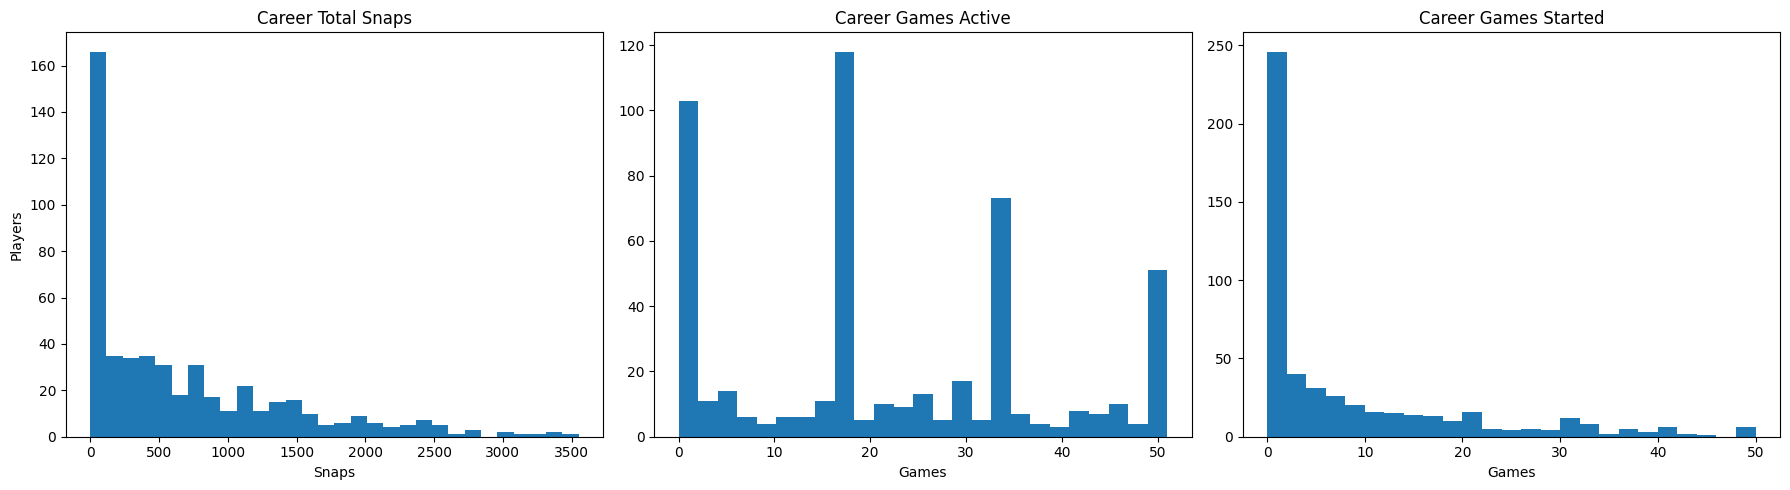

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(master["career_total_snaps"], bins=30)
axes[0].set_title("Career Total Snaps")
axes[0].set_xlabel("Snaps")
axes[0].set_ylabel("Players")

axes[1].hist(master["career_games_active"], bins=25)
axes[1].set_title("Career Games Active")
axes[1].set_xlabel("Games")

axes[2].hist(master["career_games_started"], bins=25)
axes[2].set_title("Career Games Started")
axes[2].set_xlabel("Games")

plt.tight_layout()
plt.show()

In [17]:
from sklearn.preprocessing import StandardScaler

career_features = [
    "career_total_snaps",
    "career_games_active",
    "career_games_started",
    "career_total_awards"
]

career_transformed = np.log1p(
    master[career_features]
)

career_scaled = StandardScaler().fit_transform(
    career_transformed
)

master["career_impact_score"] = career_scaled.mean(axis=1)

display(
    master[
        [
            "display_name",
            "career_total_snaps",
            "career_games_active",
            "career_games_started",
            "career_total_awards",
            "career_impact_score"
        ]
    ]
    .sort_values("career_impact_score", ascending=False)
    .head(20)
)

,display_name,career_total_snaps,career_games_active,career_games_started,career_total_awards,career_impact_score
95,Puka Nacua,2222,46,43,4,3.470225
19,Marvin Mims,1513,51,13,3,2.883700
85,Will Anderson,1976,51,44,2,2.672068
25,Jaxon Smith-Njigba,2447,51,36,2,2.655165
211,Quinyon Mitchell,1963,34,32,2,2.539350
267,Jared Verse,1754,34,33,2,2.534469
353,Chimere Dike,791,17,10,2,2.123970
125,Darnell Wright,3389,51,49,1,2.099081
77,Byron Young,2723,51,49,1,2.078668
83,Tuli Tuipulotu,3014,51,36,1,2.031461


In [18]:
impact_cutoff = master["career_impact_score"].quantile(0.75)

master["high_career_impact"] = (
    master["career_impact_score"] >= impact_cutoff
).astype(int)

print(f"75th percentile cutoff: {impact_cutoff:.3f}")

print("\nClass distribution:")
display(
    master["high_career_impact"]
    .value_counts()
    .rename(index={
        0: "Lower / Moderate Impact",
        1: "High Impact"
    })
)

75th percentile cutoff: 0.506

Class distribution:


,count
high_career_impact,
Lower / Moderate Impact,382
High Impact,128


In [19]:
traditional_features = [
    "combine_height",
    "combine_weight",
    "hand_size",
    "arm_length",
    "wing_span",
    "ten_yd_split",
    "forty",
    "vertical",
    "broad_jump",
    "three_cone",
    "short_shuttle",
    "bench_reps",
    "ngs_athleticism_score",
    "ngs_college_production_score",
    "ngs_final_score"
]

available_traditional = [
    col for col in traditional_features
    if col in master.columns
]

print("Traditional features:")
print(available_traditional)

Traditional features:
['combine_height', 'combine_weight', 'hand_size', 'arm_length', 'wing_span', 'ten_yd_split', 'forty', 'vertical', 'broad_jump', 'three_cone', 'short_shuttle', 'bench_reps', 'ngs_athleticism_score', 'ngs_college_production_score', 'ngs_final_score']


In [20]:
correlations = (
    master[
        available_traditional + ["career_impact_score"]
    ]
    .corr(numeric_only=True)["career_impact_score"]
    .drop("career_impact_score")
    .sort_values()
)

display(correlations.to_frame("correlation"))

,correlation
short_shuttle,-0.205928
three_cone,-0.131258
forty,-0.086598
ten_yd_split,-0.064054
wing_span,-0.040568
combine_height,-0.034527
combine_weight,-0.015278
arm_length,-0.002845
hand_size,0.024654
bench_reps,0.032036


In [21]:
#  Combine Drill Overview


drill_summary = (
    combine_tracking
    .groupby(["drill_type", "drill_name"])
    .agg(
        rows=("nfl_id", "size"),
        players=("nfl_id", "nunique"),
        attempts=("attempt", "nunique")
    )
    .sort_values("players", ascending=False)
)

display(drill_summary)

rows  players  \
drill_type       drill_name                                                     
FORTY_YARD_DASH  FORTY_YARD_DASH                               41500      418   
SHORT_SHUTTLE    SHORT_SHUTTLE                                 11690      170   
THREE_CONE_DRILL THREE_CONE_DRILL                              15951      160   
SKILL_DRILLS_DB  BACK_PEDAL_AND_90_DEGREE_BREAK_TO_BALL         8422      122   
                 BOX_DRILL                                      9439      122   
                 BACK_PEDAL_AND_TRANSITION_45_DEGREE_REACTION  21569      122   
                 W_DRILL                                       10214      121   
SKILL_DRILLS_OL  FIVE_YARD_WAVE_DRILL_SLIDE_AND_SHUFFLE        18087      120   
                 PASS_RUSH_DROP                                10752      120   
SKILL_DRILLS_DB  GAUNTLET_DRILL                                12253      119   
SKILL_DRILLS_OL  OL_PULL_DRILL_FOLD_BLOCK_RIGHT                 4706      119   
                 SCREEN_DRILL                                   8031      119   
SKILL_DRILLS_DL  PASS_RUSH_DRILL                                9847      114   
                 FOUR_BAG_AGILITY_DRILL                        11709      112   
                 FRONT_START_WAVE_DRILL_AND_LATERAL_REACTION   12845      112   
                 RUN_AND_CLUB_DRILL                             8180      112   
SKILL_DRILLS_DB  TERYL_AUSTIN_DRILL_2                           9514      111   
SKILL_DRILLS_DL  BODY_CONTROL_DRILL                             6611      111   
                 RUN_THE_HOOP_DRILL                             9120      109   
SKILL_DRILLS_WR  DAGGER_ROUTE_LEFT                              9917      107   
                 SLANT_ROUTE_LEFT                               5320      107   
                 GAUNTLET_DRILL                                18265      107   
                 CURL_ROUTE_RIGHT                               7993      103   
SKILL_DRILLS_DB  TERYL_AUSTIN_DRILL_1                           7765      101   
SKILL_DRILLS_WR  SLOT_STRIKE_ROUTE_LEFT                         8457      101   
                 OVER_SHOULDER_ADJUST                           8703      100   
                 SLOT_SAIL_ROUTE_RIGHT                          9524       98   
                 GO_ROUTE_RIGHT                                 9843       98   
SKILL_DRILLS_OL  OL_PULL_DRILL_DEEP_SHORT_PULL_LEFT             4412       98   
SKILL_DRILLS_WR  RED_ZONE_FADE_RIGHT                            6256       98   
                 COMEBACK_ROUTE_RIGHT                           9266       98   
                 POST_CORNER_ROUTE_RIGHT                       10517       96   
SKILL_DRILLS_OL  OL_PULL_DRILL_LONG_PULL_RIGHT                  4720       93   
SKILL_DRILLS_DB  LINE_DRILL                                    11895       85   
SKILL_DRILLS_OL  PASS_PRO-MIRROR_DRILL                          7020       84   
SKILL_DRILLS_WR  SPEED_OUT_ROUTE_LEFT                           5619       76   
                 POST_CORNER_ROUTE_LEFT                         4289       70   
SKILL_DRILLS_DL  BACK_PEDAL_AND_REACT                           6057       55   
SKILL_DRILLS_TE  FLAT_ROUTE_LEFT                                3066       42   
                 HOOK_ROUTE_RIGHT                               3986       41   
                 GAUNTLET_DRILL                                 7710       41   
                 IN_ROUTE_LEFT                                  3842       40   
                 WHEEL_ROUTE_LEFT                               3323       40   
                 BLOCK_EXPLOSION                                2330       39   
SKILL_DRILLS_WR  CIRCUS_ROUTE_LEFT                              4739       37   
SKILL_DRILLS_OL  PASS_PRO_MIRROR_DRILL                          3401       37   
SKILL_DRILLS_DL  SHORT_ZONE_BREAKS                              7895       36   
SKILL_DRILLS_DB  LINE                                           3552       33   
SKILL_DRILLS_W

In [23]:

# Drill Type Distribution


print("Drill types:")
display(
    combine_tracking["drill_type"]
    .value_counts()
    .to_frame("rows")
)

print("\nNumber of unique drill names:")
print(combine_tracking["drill_name"].nunique())

print("\nTop 20 drill names:")
display(
    combine_tracking["drill_name"]
    .value_counts()
    .head(20)
    .to_frame("rows")
)

Drill types:


,rows
drill_type,
SKILL_DRILLS_WR,120383
SKILL_DRILLS_DB,94623
SKILL_DRILLS_DL,77428
SKILL_DRILLS_OL,61129
FORTY_YARD_DASH,41500
SKILL_DRILLS_TE,37222
THREE_CONE_DRILL,15951
SHORT_SHUTTLE,11690
SKILL_DRILLS_LB,3263



Number of unique drill names:
56

Top 20 drill names:


,rows
drill_name,
FORTY_YARD_DASH,41500
GAUNTLET_DRILL,38228
BACK_PEDAL_AND_TRANSITION_45_DEGREE_REACTION,21569
FIVE_YARD_WAVE_DRILL_SLIDE_AND_SHUFFLE,18087
THREE_CONE_DRILL,15951
FRONT_START_WAVE_DRILL_AND_LATERAL_REACTION,12845
OVER_SHOULDER_ADJUST,12149
LINE_DRILL,11895
FOUR_BAG_AGILITY_DRILL,11709


In [25]:

# Drill Type Distribution


print("Drill types:")
display(
    combine_tracking["drill_type"]
    .value_counts()
    .to_frame("rows")
)

print("\nNumber of unique drill names:")
print(combine_tracking["drill_name"].nunique())

print("\nTop 20 drill names:")
display(
    combine_tracking["drill_name"]
    .value_counts()
    .head(20)
    .to_frame("rows")
)

Drill types:


,rows
drill_type,
SKILL_DRILLS_WR,120383
SKILL_DRILLS_DB,94623
SKILL_DRILLS_DL,77428
SKILL_DRILLS_OL,61129
FORTY_YARD_DASH,41500
SKILL_DRILLS_TE,37222
THREE_CONE_DRILL,15951
SHORT_SHUTTLE,11690
SKILL_DRILLS_LB,3263



Number of unique drill names:
56

Top 20 drill names:


,rows
drill_name,
FORTY_YARD_DASH,41500
GAUNTLET_DRILL,38228
BACK_PEDAL_AND_TRANSITION_45_DEGREE_REACTION,21569
FIVE_YARD_WAVE_DRILL_SLIDE_AND_SHUFFLE,18087
THREE_CONE_DRILL,15951
FRONT_START_WAVE_DRILL_AND_LATERAL_REACTION,12845
OVER_SHOULDER_ADJUST,12149
LINE_DRILL,11895
FOUR_BAG_AGILITY_DRILL,11709


In [29]:
# Tracking Entity Check

print("Entity types:")
display(
    combine_tracking["entity_type"]
    .value_counts()
    .to_frame("rows")
)

print("\nUnique entity types:")
print(combine_tracking["entity_type"].unique())

Entity types:


,rows
entity_type,
PLAYER,431094
BALL,32095



Unique entity types:
['PLAYER' 'BALL']


In [28]:
# Career Exposure By Draft Year


display(
    master.groupby("draft_year")[
        [
            "career_total_snaps",
            "career_games_active",
            "career_games_started",
            "career_total_awards"
        ]
    ].agg(["count", "mean", "median"])
)

career_total_snaps                     career_games_active  \
                        count         mean median               count   
draft_year                                                              
2023                      160  1060.187500  789.5                 160   
2024                      177   679.175141  498.0                 177   
2025                      173   315.156069  194.0                 173   

                             career_games_started                    \
                 mean median                count       mean median   
draft_year                                                            
2023        33.056250   40.5                  160  12.475000    5.0   
2024        21.943503   26.0                  177   8.000000    2.0   
2025        11.011561   17.0                  173   3.427746    0.0   

           career_total_awards                   
                         count      mean median  
draft_year                                       
2023                       160  0.093750    0.0  
2024                       177  0.028249    0.0  
2025                       173  0.011561    0.0

In [30]:

# Draft-Year Normalised Career Impact


# Percentile ranks within each draft class
master["snaps_percentile"] = (
    master.groupby("draft_year")["career_total_snaps"]
    .rank(pct=True)
)

master["active_games_percentile"] = (
    master.groupby("draft_year")["career_games_active"]
    .rank(pct=True)
)

master["started_games_percentile"] = (
    master.groupby("draft_year")["career_games_started"]
    .rank(pct=True)
)

# Recognition is kept as a secondary signal rather than
# allowing the small award counts to dominate the target.
master["recognition_percentile"] = (
    master.groupby("draft_year")["career_total_awards"]
    .rank(pct=True)
)

master["career_impact_normalized"] = (
    master["snaps_percentile"] +
    master["active_games_percentile"] +
    master["started_games_percentile"] +
    master["recognition_percentile"]
) / 4

display(
    master[
        [
            "display_name",
            "draft_year",
            "career_total_snaps",
            "career_games_active",
            "career_games_started",
            "career_total_awards",
            "career_impact_normalized"
        ]
    ]
    .sort_values("career_impact_normalized", ascending=False)
    .head(20)
)

,display_name,draft_year,career_total_snaps,career_games_active,career_games_started,career_total_awards,career_impact_normalized
125,Darnell Wright,2023,3389,51,49,1,0.953125
77,Byron Young,2023,2723,51,49,1,0.940625
211,Quinyon Mitchell,2024,1963,34,32,2,0.939266
267,Jared Verse,2024,1754,34,33,2,0.934322
83,Tuli Tuipulotu,2023,3014,51,36,1,0.917188
85,Will Anderson,2023,1976,51,44,2,0.900000
25,Jaxon Smith-Njigba,2023,2447,51,36,2,0.898438
353,Chimere Dike,2025,791,17,10,2,0.876445
95,Puka Nacua,2023,2222,46,43,4,0.854688
118,Brian Branch,2023,2518,46,37,1,0.852344


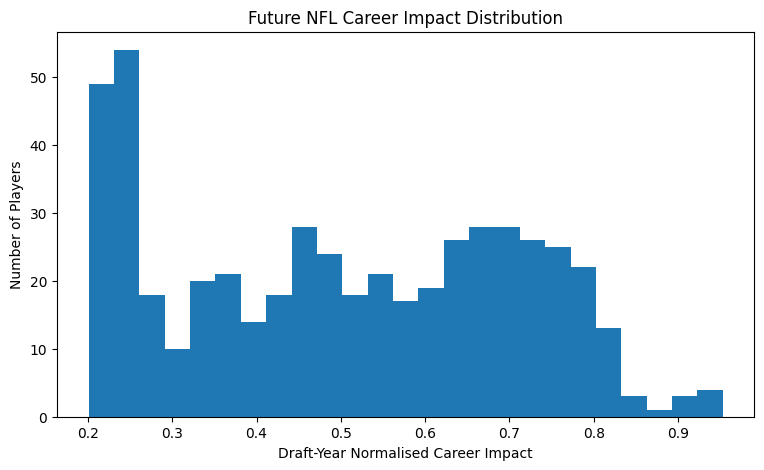

In [31]:
# Normalised Target Distribution


import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.hist(
    master["career_impact_normalized"],
    bins=25
)

plt.xlabel("Draft-Year Normalised Career Impact")
plt.ylabel("Number of Players")
plt.title("Future NFL Career Impact Distribution")

plt.show()

In [32]:
# Sensor-Derived Movement Features


tracking = combine_tracking.copy()

# Make sure numerical columns are numeric
sensor_cols = ["x", "y", "s", "a", "dis", "dir"]

for col in sensor_cols:
    tracking[col] = pd.to_numeric(tracking[col], errors="coerce")

# Convert direction to radians for circular calculations
tracking["dir_rad"] = np.deg2rad(tracking["dir"])

# Directional components of velocity
tracking["vx"] = tracking["s"] * np.cos(tracking["dir_rad"])
tracking["vy"] = tracking["s"] * np.sin(tracking["dir_rad"])

# Directional components of acceleration
tracking["ax"] = tracking["a"] * np.cos(tracking["dir_rad"])
tracking["ay"] = tracking["a"] * np.sin(tracking["dir_rad"])

# Absolute movement quantities
tracking["speed_sq"] = tracking["s"] ** 2
tracking["acceleration_abs"] = tracking["a"].abs()
tracking["distance_abs"] = tracking["dis"].abs()

display(
    tracking[
        [
            "nfl_id",
            "drill_name",
            "attempt",
            "s",
            "a",
            "dis",
            "dir",
            "vx",
            "vy",
            "ax",
            "ay"
        ]
    ].head()
)

,nfl_id,drill_name,attempt,s,a,dis,dir,vx,vy,ax,ay
0,58286,OL_PULL_DRILL_FOLD_BLOCK_RIGHT,4,0.220828,0.682443,0.011085,250.278576,-0.074518,-0.207875,-0.230288,-0.642414
1,58286,OL_PULL_DRILL_FOLD_BLOCK_RIGHT,4,0.332931,0.619551,0.003864,257.319206,-0.073085,-0.324811,-0.136003,-0.604439
2,58286,OL_PULL_DRILL_FOLD_BLOCK_RIGHT,4,0.481838,0.596455,0.008305,253.176813,-0.139453,-0.461217,-0.172626,-0.570928
3,58286,OL_PULL_DRILL_FOLD_BLOCK_RIGHT,4,0.599350,0.664436,0.007964,247.044153,-0.233760,-0.551885,-0.259144,-0.611816
4,58286,OL_PULL_DRILL_FOLD_BLOCK_RIGHT,4,0.657540,0.908250,0.005382,240.622668,-0.322562,-0.572985,-0.445550,-0.791456


In [33]:
# Movement Statistics Per Player / Drill / Attempt


attempt_features = (
    tracking
    .groupby(
        ["nfl_id", "draft_year", "drill_type", "drill_name", "attempt"],
        dropna=False
    )
    .agg(
        duration=("time", "count"),

        mean_speed=("s", "mean"),
        max_speed=("s", "max"),
        speed_std=("s", "std"),

        mean_acceleration=("a", "mean"),
        max_acceleration=("a", "max"),
        acceleration_std=("a", "std"),

        total_distance=("dis", "sum"),
        mean_distance=("dis", "mean"),

        mean_abs_acceleration=("acceleration_abs", "mean"),

        mean_vx=("vx", "mean"),
        mean_vy=("vy", "mean"),

        max_x=("x", "max"),
        min_x=("x", "min"),
        max_y=("y", "max"),
        min_y=("y", "min")
    )
    .reset_index()
)

print("Attempt-level feature table:", attempt_features.shape)

display(attempt_features.head())

Attempt-level feature table: (6301, 21)


,nfl_id,draft_year,drill_type,drill_name,attempt,duration,mean_speed,max_speed,speed_std,mean_acceleration,max_acceleration,acceleration_std,total_distance,mean_distance,mean_abs_acceleration,mean_vx,mean_vy,max_x,min_x,max_y,min_y
0,55867,2023,FORTY_YARD_DASH,FORTY_YARD_DASH,2,52,7.966603,10.416667,3.034755,1.921288,5.859557,1.887961,37.234769,0.716053,1.921288,-0.003192,7.962782,51.766667,10.833333,-0.600000,-0.866667
1,55867,2023,SKILL_DRILLS_LB,BACK_PEDAL_AND_REACT,1,115,4.408319,6.950000,1.742780,2.899156,6.550740,1.704968,24.028678,0.208945,2.899156,-0.034803,-0.950157,59.900000,34.500000,25.533333,15.566667
2,55867,2023,SKILL_DRILLS_LB,FOUR_BAG_SHUFFLE_DRILL,1,128,3.586276,8.070000,2.296045,3.047883,6.371730,1.591590,19.347421,0.151152,3.047883,0.940690,-1.173749,46.733333,31.600000,46.766667,24.700000
3,55867,2023,SKILL_DRILLS_LB,PASS_RUSH_DRILL,1,44,5.578485,8.630000,2.797801,3.120578,6.007893,1.844972,15.730084,0.357502,3.120578,-4.404984,2.175901,52.666667,43.066667,31.600000,12.666667
4,55867,2023,SKILL_DRILLS_LB,PASS_RUSH_DRILL,2,51,4.957582,8.443333,2.834661,2.681002,5.405176,1.695268,15.481750,0.303564,2.681002,4.015915,1.631951,51.433333,42.900000,41.800000,21.700000


In [34]:
# Movement Efficiency Features


attempt_features["distance_per_acceleration"] = (
    attempt_features["total_distance"] /
    (attempt_features["mean_abs_acceleration"] + 1e-6)
)

attempt_features["speed_to_acceleration"] = (
    attempt_features["max_speed"] /
    (attempt_features["max_acceleration"].abs() + 1e-6)
)

attempt_features["movement_range_x"] = (
    attempt_features["max_x"] - attempt_features["min_x"]
)

attempt_features["movement_range_y"] = (
    attempt_features["max_y"] - attempt_features["min_y"]
)

display(
    attempt_features[
        [
            "nfl_id",
            "drill_name",
            "attempt",
            "max_speed",
            "max_acceleration",
            "total_distance",
            "distance_per_acceleration",
            "speed_to_acceleration"
        ]
    ].head(10)
)

,nfl_id,drill_name,attempt,max_speed,max_acceleration,total_distance,distance_per_acceleration,speed_to_acceleration
0,55867,FORTY_YARD_DASH,2,10.416667,5.859557,37.234769,19.380097,1.777722
1,55867,BACK_PEDAL_AND_REACT,1,6.950000,6.550740,24.028678,8.288161,1.060949
2,55867,FOUR_BAG_SHUFFLE_DRILL,1,8.070000,6.371730,19.347421,6.347821,1.266532
3,55867,PASS_RUSH_DRILL,1,8.630000,6.007893,15.730084,5.040759,1.436443
4,55867,PASS_RUSH_DRILL,2,8.443333,5.405176,15.481750,5.774611,1.562083
5,55867,SHORT_ZONE_BREAKS,1,7.963333,5.704116,18.555349,5.747063,1.396068
6,55867,SHORT_ZONE_BREAKS,2,8.523333,6.402993,31.136294,10.081014,1.331148
7,55867,SHORT_ZONE_BREAKS,4,6.343333,7.592350,13.740120,4.682766,0.835490
8,55867,SHUFFLE_SPRINT_AND_COD_DRILL,1,7.160000,8.137175,27.119249,11.653823,0.879912
9,55867,WAVE_DRILL,1,6.873333,6.281660,18.765530,6.898176,1.094190


In [35]:
# Aggregate Attempts Into Player-Level Drill Features


drill_features = (
    attempt_features
    .groupby(
        ["nfl_id", "draft_year", "drill_type", "drill_name"],
        dropna=False
    )
    .agg(
        mean_speed=("mean_speed", "mean"),
        max_speed=("max_speed", "max"),
        speed_consistency=("speed_std", "mean"),

        mean_acceleration=("mean_acceleration", "mean"),
        max_acceleration=("max_acceleration", "max"),
        acceleration_consistency=("acceleration_std", "mean"),

        mean_distance=("total_distance", "mean"),
        max_distance=("total_distance", "max"),

        movement_efficiency=("distance_per_acceleration", "mean"),
        speed_acceleration_ratio=("speed_to_acceleration", "mean"),

        movement_range_x=("movement_range_x", "mean"),
        movement_range_y=("movement_range_y", "mean"),

        attempts=("attempt", "nunique")
    )
    .reset_index()
)

print("Player × drill feature table:", drill_features.shape)

display(drill_features.head())

Player × drill feature table: (4986, 17)


,nfl_id,draft_year,drill_type,drill_name,mean_speed,max_speed,speed_consistency,mean_acceleration,max_acceleration,acceleration_consistency,mean_distance,max_distance,movement_efficiency,speed_acceleration_ratio,movement_range_x,movement_range_y,attempts
0,55867,2023,FORTY_YARD_DASH,FORTY_YARD_DASH,7.966603,10.416667,3.034755,1.921288,5.859557,1.887961,37.234769,37.234769,19.380097,1.777722,40.933333,0.266667,1
1,55867,2023,SKILL_DRILLS_LB,BACK_PEDAL_AND_REACT,4.408319,6.950000,1.742780,2.899156,6.550740,1.704968,24.028678,24.028678,8.288161,1.060949,25.400000,9.966667,1
2,55867,2023,SKILL_DRILLS_LB,FOUR_BAG_SHUFFLE_DRILL,3.586276,8.070000,2.296045,3.047883,6.371730,1.591590,19.347421,19.347421,6.347821,1.266532,15.133333,22.066667,1
3,55867,2023,SKILL_DRILLS_LB,PASS_RUSH_DRILL,5.268033,8.630000,2.816231,2.900790,6.007893,1.770120,15.605917,15.730084,5.407685,1.499263,9.066667,19.516667,2
4,55867,2023,SKILL_DRILLS_LB,SHORT_ZONE_BREAKS,5.013397,8.523333,2.036163,3.083820,7.592350,1.727545,21.143921,31.136294,6.836948,1.187569,20.122222,15.011111,3


In [36]:
# Overall Player Movement Signature


movement_features = (
    drill_features
    .groupby(["nfl_id", "draft_year"])
    .agg(
        sensor_drills=("drill_name", "nunique"),

        mean_speed=("mean_speed", "mean"),
        peak_speed=("max_speed", "max"),
        speed_variability=("speed_consistency", "mean"),

        mean_acceleration=("mean_acceleration", "mean"),
        peak_acceleration=("max_acceleration", "max"),
        acceleration_variability=("acceleration_consistency", "mean"),

        mean_distance=("mean_distance", "mean"),
        peak_distance=("max_distance", "max"),

        movement_efficiency=("movement_efficiency", "mean"),
        speed_acceleration_ratio=("speed_acceleration_ratio", "mean"),

        movement_range_x=("movement_range_x", "mean"),
        movement_range_y=("movement_range_y", "mean"),

        total_attempts=("attempts", "sum")
    )
    .reset_index()
)

print("Player movement signature:", movement_features.shape)

display(movement_features.head())

Player movement signature: (510, 16)


,nfl_id,draft_year,sensor_drills,mean_speed,peak_speed,speed_variability,mean_acceleration,peak_acceleration,acceleration_variability,mean_distance,peak_distance,movement_efficiency,speed_acceleration_ratio,movement_range_x,movement_range_y,total_attempts
0,55867,2023,7,4.920093,10.416667,2.274576,2.700052,8.137175,1.750111,23.320783,37.234769,9.258959,1.252305,19.079365,14.084921,10
1,55870,2023,7,3.221248,8.213333,2.190324,2.921993,6.552510,1.515057,9.477348,19.128368,3.219726,1.333790,12.550000,7.923810,8
2,55874,2023,8,3.806837,10.073333,2.271284,2.617415,6.696734,1.439292,12.675930,34.562950,5.341954,1.417066,16.404167,6.900000,9
3,55875,2023,10,3.589057,9.253333,1.893004,2.702584,6.790909,1.505404,11.289006,32.204316,4.857061,1.291344,14.333333,6.408333,12
4,55877,2023,11,4.154234,10.640000,2.012367,3.158809,8.923861,1.795244,14.459553,36.735855,5.279171,1.159751,14.456566,9.021717,18


In [37]:
# Feature Quality Check


feature_quality = pd.DataFrame({
    "missing": movement_features.isna().sum(),
    "missing_pct": movement_features.isna().mean() * 100,
    "unique": movement_features.nunique()
})

display(
    feature_quality
    .sort_values("missing_pct", ascending=False)
)

,missing,missing_pct,unique
nfl_id,0,0.0,510
draft_year,0,0.0,3
sensor_drills,0,0.0,12
mean_speed,0,0.0,510
peak_speed,0,0.0,460
speed_variability,0,0.0,510
mean_acceleration,0,0.0,510
peak_acceleration,0,0.0,510
acceleration_variability,0,0.0,510
mean_distance,0,0.0,510


In [38]:
# Clean Sensor Features


sensor_feature_cols = [
    col for col in movement_features.columns
    if col not in ["nfl_id", "draft_year"]
]

# Replace infinite values
movement_features[sensor_feature_cols] = (
    movement_features[sensor_feature_cols]
    .replace([np.inf, -np.inf], np.nan)
)

print("Sensor features:")
print(sensor_feature_cols)

print("\nPlayers with sensor features:",
      movement_features["nfl_id"].nunique())

Sensor features:
['sensor_drills', 'mean_speed', 'peak_speed', 'speed_variability', 'mean_acceleration', 'peak_acceleration', 'acceleration_variability', 'mean_distance', 'peak_distance', 'movement_efficiency', 'speed_acceleration_ratio', 'movement_range_x', 'movement_range_y', 'total_attempts']

Players with sensor features: 510


In [39]:
# Final Modelling Dataset


model_data = master.merge(
    movement_features,
    on=["nfl_id", "draft_year"],
    how="inner"
)

print("Final modelling dataset:", model_data.shape)

print(
    "Players retained:",
    model_data["nfl_id"].nunique()
)

display(
    model_data[
        [
            "display_name",
            "draft_year",
            "career_impact_normalized",
            "mean_speed",
            "peak_speed",
            "mean_acceleration",
            "peak_acceleration",
            "movement_efficiency"
        ]
    ].head(10)
)

Final modelling dataset: (510, 57)
Players retained: 510


,display_name,draft_year,career_impact_normalized,mean_speed,peak_speed,mean_acceleration,peak_acceleration,movement_efficiency
0,Davis Allen,2023,0.668750,5.646853,9.960000,2.541670,6.646133,10.255269
1,Jammie Robinson,2023,0.457031,5.643836,10.760000,2.696613,7.399643,11.733955
2,Zack Kuntz,2023,0.248438,5.125012,11.020000,2.815880,8.002651,8.343078
3,Trey Palmer,2023,0.539062,5.904435,11.486667,3.250236,8.772843,9.275295
4,Ronnie Bell,2023,0.348438,5.754654,10.766667,3.399652,8.337399,8.167106
5,Quentin Johnston,2023,0.741406,5.712825,10.370000,3.370648,7.702788,7.569660
6,Michael Mayer,2023,0.672656,5.585919,10.246667,2.532581,7.134287,9.547545
7,Rashee Rice,2023,0.545312,5.818393,10.936667,3.221011,8.494507,9.089385
8,Dontay Demus,2023,0.200781,5.713996,10.820000,3.171699,9.113334,9.116821
9,Darrell Luter,2023,0.450781,5.144179,11.180000,3.168796,8.687683,8.785201


In [40]:
# Sensor Feature Correlations


sensor_correlations = []

for feature in sensor_feature_cols:

    if feature in model_data.columns:

        corr = model_data[
            [feature, "career_impact_normalized"]
        ].corr().iloc[0, 1]

        sensor_correlations.append(
            {
                "feature": feature,
                "correlation": corr
            }
        )

sensor_correlations = (
    pd.DataFrame(sensor_correlations)
    .dropna()
    .sort_values("correlation", key=abs, ascending=False)
)

display(sensor_correlations)

,feature,correlation
4,mean_acceleration,0.074189
9,movement_efficiency,-0.048710
10,speed_acceleration_ratio,-0.046237
8,peak_distance,-0.041565
7,mean_distance,-0.040739
12,movement_range_y,-0.027400
5,peak_acceleration,-0.026265
3,speed_variability,-0.024906
2,peak_speed,-0.024400
6,acceleration_variability,0.022990


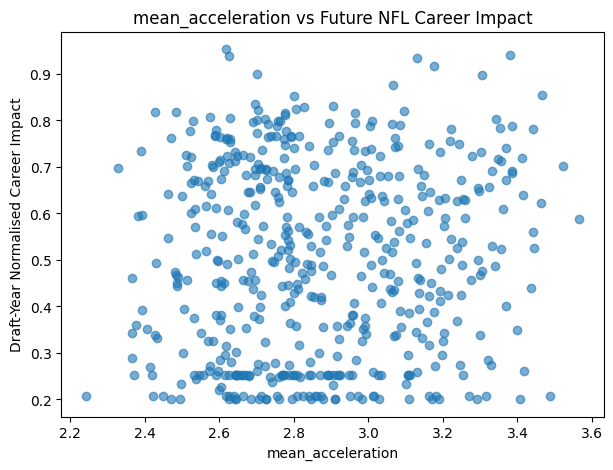

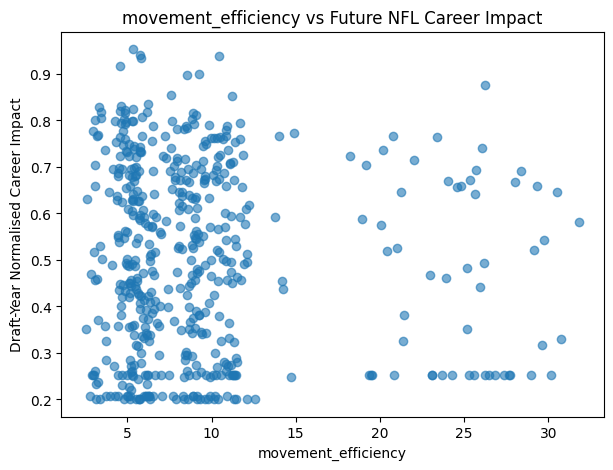

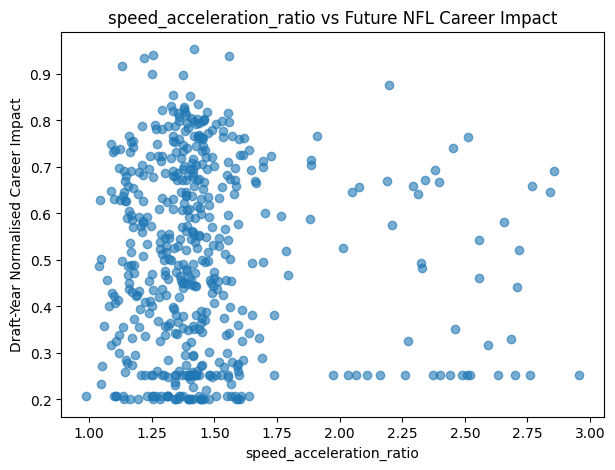

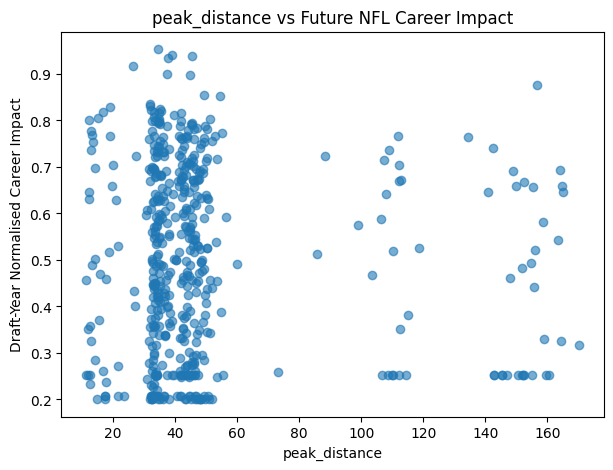

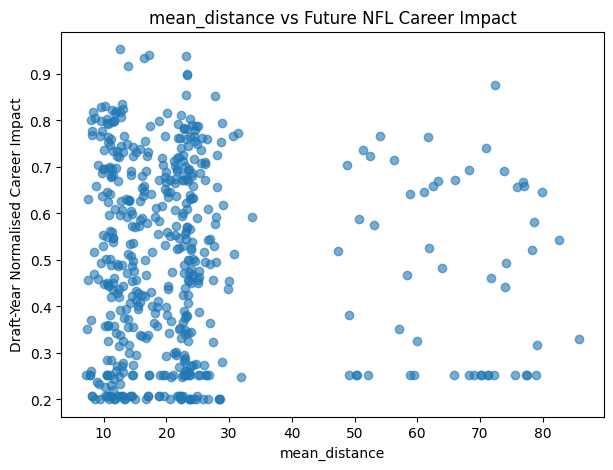

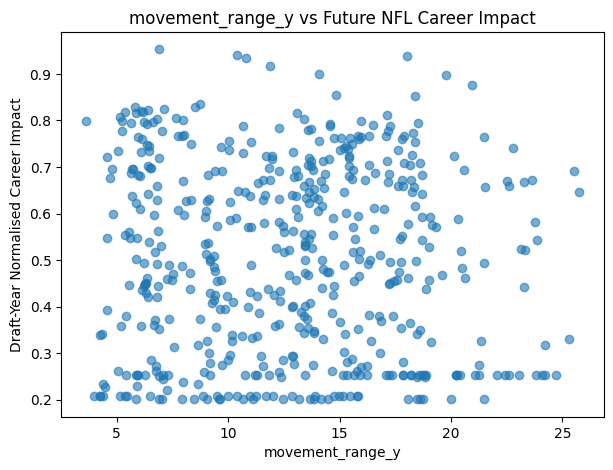

In [41]:
# Strongest Sensor Relationships


top_sensor_features = (
    sensor_correlations
    .head(6)["feature"]
    .tolist()
)

for feature in top_sensor_features:

    plt.figure(figsize=(7, 5))

    plt.scatter(
        model_data[feature],
        model_data["career_impact_normalized"],
        alpha=0.6
    )

    plt.xlabel(feature)
    plt.ylabel("Draft-Year Normalised Career Impact")
    plt.title(f"{feature} vs Future NFL Career Impact")

    plt.show()

In [42]:
# Compare Information Sources


traditional_features = [
    "combine_height",
    "combine_weight",
    "hand_size",
    "arm_length",
    "wing_span",
    "ten_yd_split",
    "forty",
    "vertical",
    "broad_jump",
    "three_cone",
    "short_shuttle",
    "bench_reps"
]

ngs_features = [
    "ngs_athleticism_score",
    "ngs_college_production_score",
    "ngs_final_score"
]

sensor_features = sensor_feature_cols

comparison = pd.DataFrame({
    "Feature Group": [
        "Traditional Combine",
        "NGS Scouting Scores",
        "Sensor Movement"
    ],
    "Number of Features": [
        len(traditional_features),
        len(ngs_features),
        len(sensor_features)
    ]
})

display(comparison)

,Feature Group,Number of Features
0,Traditional Combine,12
1,NGS Scouting Scores,3
2,Sensor Movement,14


In [43]:
# Modelling Feature Groups


traditional_available = [
    f for f in traditional_features
    if f in model_data.columns
]

ngs_available = [
    f for f in ngs_features
    if f in model_data.columns
]

sensor_available = [
    f for f in sensor_features
    if f in model_data.columns
]

print("Traditional:", traditional_available)
print("\nNGS:", ngs_available)
print("\nSensor:", sensor_available)

print("\nFeature counts:")
print("Traditional:", len(traditional_available))
print("NGS:", len(ngs_available))
print("Sensor:", len(sensor_available))

Traditional: ['combine_height', 'combine_weight', 'hand_size', 'arm_length', 'wing_span', 'ten_yd_split', 'forty', 'vertical', 'broad_jump', 'three_cone', 'short_shuttle', 'bench_reps']

NGS: ['ngs_athleticism_score', 'ngs_college_production_score', 'ngs_final_score']

Sensor: ['sensor_drills', 'mean_speed', 'peak_speed', 'speed_variability', 'mean_acceleration', 'peak_acceleration', 'acceleration_variability', 'mean_distance', 'peak_distance', 'movement_efficiency', 'speed_acceleration_ratio', 'movement_range_x', 'movement_range_y', 'total_attempts']

Feature counts:
Traditional: 12
NGS: 3
Sensor: 14


In [44]:
# Prepare Modelling Data


from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

target = "career_impact_normalized"

# Keep only players with a valid target
model_data_clean = model_data.dropna(subset=[target]).copy()

print("Players available for modelling:", len(model_data_clean))

Players available for modelling: 510


In [45]:
# Four Information Sets


X_traditional = model_data_clean[traditional_available]

X_baseline = model_data_clean[
    traditional_available + ngs_available
]

X_sensor = model_data_clean[
    sensor_available
]

X_combined = model_data_clean[
    traditional_available + ngs_available + sensor_available
]

y = model_data_clean[target]

print("Traditional:", X_traditional.shape)
print("Traditional + NGS:", X_baseline.shape)
print("Sensor:", X_sensor.shape)
print("Combined:", X_combined.shape)

Traditional: (510, 12)
Traditional + NGS: (510, 15)
Sensor: (510, 14)
Combined: (510, 29)


In [46]:
#  Cross-Validation Setup


cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

ridge = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=10.0))
])

rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=400,
        max_depth=6,
        min_samples_leaf=4,
        random_state=42,
        n_jobs=-1
    ))
])

In [47]:
# Model Evaluation Function


def evaluate_model(model, X, y, name):

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring={
            "r2": "r2",
            "mae": "neg_mean_absolute_error"
        },
        n_jobs=-1
    )

    result = {
        "model": name,
        "R2_mean": scores["test_r2"].mean(),
        "R2_std": scores["test_r2"].std(),
        "MAE_mean": -scores["test_mae"].mean(),
        "MAE_std": scores["test_mae"].std()
    }

    return result

In [48]:
# Model Evaluation Function


def evaluate_model(model, X, y, name):

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring={
            "r2": "r2",
            "mae": "neg_mean_absolute_error"
        },
        n_jobs=-1
    )

    result = {
        "model": name,
        "R2_mean": scores["test_r2"].mean(),
        "R2_std": scores["test_r2"].std(),
        "MAE_mean": -scores["test_mae"].mean(),
        "MAE_std": scores["test_mae"].std()
    }

    return result

In [50]:
# Ridge Regression Comparison


ridge_results = []

ridge_results.append(
    evaluate_model(
        ridge,
        X_traditional,
        y,
        "A: Traditional Combine"
    )
)

ridge_results.append(
    evaluate_model(
        ridge,
        X_baseline,
        y,
        "B: Traditional + NGS"
    )
)

ridge_results.append(
    evaluate_model(
        ridge,
        X_sensor,
        y,
        "C: Sensor Movement"
    )
)

ridge_results.append(
    evaluate_model(
        ridge,
        X_combined,
        y,
        "D: Traditional + NGS + Sensor"
    )
)

ridge_results = pd.DataFrame(ridge_results)

display(
    ridge_results.sort_values("R2_mean", ascending=False)
)

,model,R2_mean,R2_std,MAE_mean,MAE_std
1,B: Traditional + NGS,0.300820,0.090282,0.140939,0.007641
3,D: Traditional + NGS + Sensor,0.294372,0.085915,0.141254,0.006413
0,A: Traditional Combine,0.013216,0.033659,0.173630,0.008444
2,C: Sensor Movement,-0.001957,0.025402,0.175896,0.009480


In [49]:
# Random Forest Comparison


rf_results = []

rf_results.append(
    evaluate_model(
        rf,
        X_traditional,
        y,
        "A: Traditional Combine"
    )
)

rf_results.append(
    evaluate_model(
        rf,
        X_baseline,
        y,
        "B: Traditional + NGS"
    )
)

rf_results.append(
    evaluate_model(
        rf,
        X_sensor,
        y,
        "C: Sensor Movement"
    )
)

rf_results.append(
    evaluate_model(
        rf,
        X_combined,
        y,
        "D: Traditional + NGS + Sensor"
    )
)

rf_results = pd.DataFrame(rf_results)

display(
    rf_results.sort_values("R2_mean", ascending=False)
)

,model,R2_mean,R2_std,MAE_mean,MAE_std
1,B: Traditional + NGS,0.345510,0.069861,0.134141,0.006770
3,D: Traditional + NGS + Sensor,0.343384,0.064741,0.135239,0.006108
0,A: Traditional Combine,0.061284,0.028229,0.168123,0.011222
2,C: Sensor Movement,-0.010005,0.034914,0.177166,0.009203


In [51]:
# Incremental Sensor Value


ridge_baseline_r2 = ridge_results.loc[
    ridge_results["model"] == "B: Traditional + NGS",
    "R2_mean"
].iloc[0]

ridge_combined_r2 = ridge_results.loc[
    ridge_results["model"] == "D: Traditional + NGS + Sensor",
    "R2_mean"
].iloc[0]

rf_baseline_r2 = rf_results.loc[
    rf_results["model"] == "B: Traditional + NGS",
    "R2_mean"
].iloc[0]

rf_combined_r2 = rf_results.loc[
    rf_results["model"] == "D: Traditional + NGS + Sensor",
    "R2_mean"
].iloc[0]

incremental_results = pd.DataFrame({
    "Model": ["Ridge", "Random Forest"],
    "Baseline_R2": [
        ridge_baseline_r2,
        rf_baseline_r2
    ],
    "Combined_R2": [
        ridge_combined_r2,
        rf_combined_r2
    ],
    "Sensor_R2_Gain": [
        ridge_combined_r2 - ridge_baseline_r2,
        rf_combined_r2 - rf_baseline_r2
    ]
})

display(incremental_results)

,Model,Baseline_R2,Combined_R2,Sensor_R2_Gain
0,Ridge,0.30082,0.294372,-0.006448
1,Random Forest,0.34551,0.343384,-0.002126


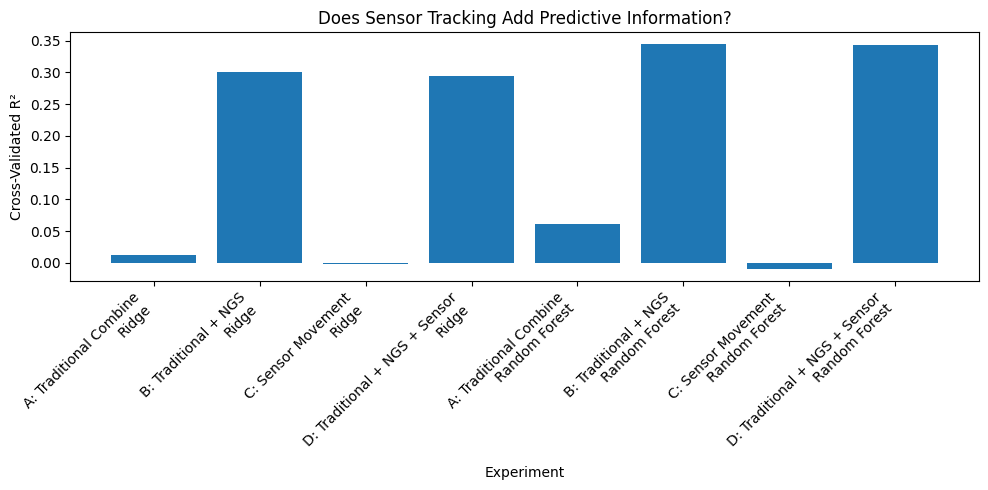

In [52]:
# Model Performance


plt.figure(figsize=(10, 5))

all_results = pd.concat([
    ridge_results.assign(algorithm="Ridge"),
    rf_results.assign(algorithm="Random Forest")
])

labels = all_results["model"] + "\n" + all_results["algorithm"]

plt.bar(
    labels,
    all_results["R2_mean"]
)

plt.ylabel("Cross-Validated R²")
plt.xlabel("Experiment")
plt.title("Does Sensor Tracking Add Predictive Information?")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [53]:
# Sensor Feature Importance


sensor_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=500,
        max_depth=7,
        min_samples_leaf=4,
        random_state=42,
        n_jobs=-1
    ))
])

sensor_model.fit(X_sensor, y)

rf_sensor = sensor_model.named_steps["model"]

importance = pd.DataFrame({
    "feature": sensor_available,
    "importance": rf_sensor.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

display(importance)

,feature,importance
4,mean_acceleration,0.118827
5,peak_acceleration,0.110499
12,movement_range_y,0.110274
3,speed_variability,0.090640
6,acceleration_variability,0.085791
2,peak_speed,0.082225
1,mean_speed,0.064528
8,peak_distance,0.063928
9,movement_efficiency,0.062119
10,speed_acceleration_ratio,0.058427


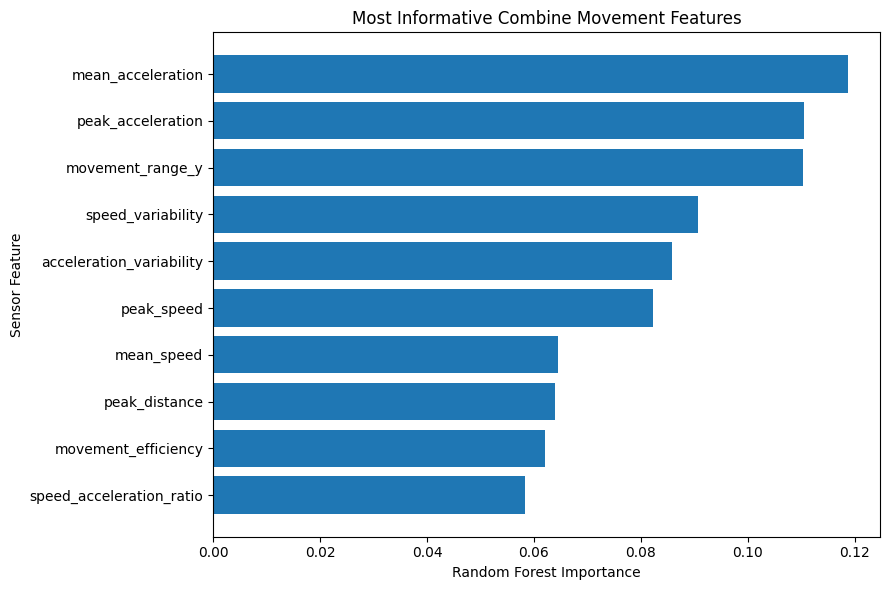

In [54]:
# Sensor Feature Importance Plot


top_features = importance.head(10).sort_values("importance")

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Random Forest Importance")
plt.ylabel("Sensor Feature")
plt.title("Most Informative Combine Movement Features")

plt.tight_layout()
plt.show()

In [55]:
# Relative Improvement


comparison = incremental_results.copy()

comparison["Relative_R2_Improvement_%"] = (
    (comparison["Combined_R2"] - comparison["Baseline_R2"])
    / comparison["Baseline_R2"].abs().replace(0, np.nan)
) * 100

display(comparison)

,Model,Baseline_R2,Combined_R2,Sensor_R2_Gain,Relative_R2_Improvement_%
0,Ridge,0.30082,0.294372,-0.006448,-2.143359
1,Random Forest,0.34551,0.343384,-0.002126,-0.615436


In [56]:
# Final Model Comparison


final_results = pd.concat([
    ridge_results.assign(algorithm="Ridge"),
    rf_results.assign(algorithm="Random Forest")
])

final_results = final_results[
    [
        "algorithm",
        "model",
        "R2_mean",
        "R2_std",
        "MAE_mean",
        "MAE_std"
    ]
].sort_values(
    "R2_mean",
    ascending=False
)

display(final_results)

,algorithm,model,R2_mean,R2_std,MAE_mean,MAE_std
1,Random Forest,B: Traditional + NGS,0.345510,0.069861,0.134141,0.006770
3,Random Forest,D: Traditional + NGS + Sensor,0.343384,0.064741,0.135239,0.006108
1,Ridge,B: Traditional + NGS,0.300820,0.090282,0.140939,0.007641
3,Ridge,D: Traditional + NGS + Sensor,0.294372,0.085915,0.141254,0.006413
0,Random Forest,A: Traditional Combine,0.061284,0.028229,0.168123,0.011222
0,Ridge,A: Traditional Combine,0.013216,0.033659,0.173630,0.008444
2,Ridge,C: Sensor Movement,-0.001957,0.025402,0.175896,0.009480
2,Random Forest,C: Sensor Movement,-0.010005,0.034914,0.177166,0.009203


In [59]:
# Best Model


best_row = final_results.iloc[0]

print("BEST MODEL")
print("-" * 40)
print("Algorithm:", best_row["algorithm"])
print("Experiment:", best_row["model"])
print(f"Cross-validated R²: {best_row['R2_mean']:.4f}")
print(f"Cross-validated MAE: {best_row['MAE_mean']:.4f}")

BEST MODEL
----------------------------------------
Algorithm: Random Forest
Experiment: B: Traditional + NGS
Cross-validated R²: 0.3455
Cross-validated MAE: 0.1341


In [58]:
# Research Result Summary


best_ridge_gain = incremental_results.loc[
    incremental_results["Model"] == "Ridge",
    "Sensor_R2_Gain"
].iloc[0]

best_rf_gain = incremental_results.loc[
    incremental_results["Model"] == "Random Forest",
    "Sensor_R2_Gain"
].iloc[0]

print("RESEARCH QUESTION")
print("=" * 60)
print(
    "Do 10-Hz Combine sensor movement features provide "
    "additional information about future NFL career success "
    "beyond traditional Combine and NGS measurements?"
)

print("\nKEY RESULT")
print("=" * 60)
print(f"Ridge incremental R²: {best_ridge_gain:+.4f}")
print(f"Random Forest incremental R²: {best_rf_gain:+.4f}")

if max(best_ridge_gain, best_rf_gain) > 0:
    print(
        "\nSensor tracking adds predictive information "
        "beyond the conventional baseline."
    )
else:
    print(
        "\nSensor tracking did not improve the baseline "
        "under the current feature design."
    )

RESEARCH QUESTION
Do 10-Hz Combine sensor movement features provide additional information about future NFL career success beyond traditional Combine and NGS measurements?

KEY RESULT
Ridge incremental R²: -0.0064
Random Forest incremental R²: -0.0021

Sensor tracking did not improve the baseline under the current feature design.


In [62]:
# Drill-Specific Movement Features


# First inspect what we actually have
print("Available attempt-level columns:")
print(attempt_features.columns.tolist())

# Build only from columns that exist
drill_player_features = (
    attempt_features
    .groupby(
        ["nfl_id", "draft_year", "drill_name"],
        dropna=False
    )
    .agg(
        mean_speed=("mean_speed", "mean"),
        peak_speed=("max_speed", "max"),
        speed_variability=("speed_std", "mean"),

        mean_acceleration=("mean_acceleration", "mean"),
        peak_acceleration=("max_acceleration", "max"),
        acceleration_variability=("acceleration_std", "mean"),

        mean_distance=("total_distance", "mean"),
        peak_distance=("total_distance", "max"),

        movement_efficiency=("distance_per_acceleration", "mean"),

        range_x=("movement_range_x", "mean"),
        range_y=("movement_range_y", "mean"),

        attempts=("attempt", "nunique")
    )
    .reset_index()
)

print("\nDrill-specific feature table:", drill_player_features.shape)

display(drill_player_features.head())

Available attempt-level columns:
['nfl_id', 'draft_year', 'drill_type', 'drill_name', 'attempt', 'duration', 'mean_speed', 'max_speed', 'speed_std', 'mean_acceleration', 'max_acceleration', 'acceleration_std', 'total_distance', 'mean_distance', 'mean_abs_acceleration', 'mean_vx', 'mean_vy', 'max_x', 'min_x', 'max_y', 'min_y', 'distance_per_acceleration', 'speed_to_acceleration', 'movement_range_x', 'movement_range_y']

Drill-specific feature table: (4986, 15)


,nfl_id,draft_year,drill_name,mean_speed,peak_speed,speed_variability,mean_acceleration,peak_acceleration,acceleration_variability,mean_distance,peak_distance,movement_efficiency,range_x,range_y,attempts
0,55867,2023,BACK_PEDAL_AND_REACT,4.408319,6.950000,1.742780,2.899156,6.550740,1.704968,24.028678,24.028678,8.288161,25.400000,9.966667,1
1,55867,2023,FORTY_YARD_DASH,7.966603,10.416667,3.034755,1.921288,5.859557,1.887961,37.234769,37.234769,19.380097,40.933333,0.266667,1
2,55867,2023,FOUR_BAG_SHUFFLE_DRILL,3.586276,8.070000,2.296045,3.047883,6.371730,1.591590,19.347421,19.347421,6.347821,15.133333,22.066667,1
3,55867,2023,PASS_RUSH_DRILL,5.268033,8.630000,2.816231,2.900790,6.007893,1.770120,15.605917,15.730084,5.407685,9.066667,19.516667,2
4,55867,2023,SHORT_ZONE_BREAKS,5.013397,8.523333,2.036163,3.083820,7.592350,1.727545,21.143921,31.136294,6.836948,20.122222,15.011111,3


In [63]:
# Players per Drill


drill_counts = (
    drill_player_features
    .groupby("drill_name")["nfl_id"]
    .nunique()
    .sort_values(ascending=False)
)

display(drill_counts.to_frame("players").head(30))

,players
drill_name,
FORTY_YARD_DASH,418
GAUNTLET_DRILL,267
SHORT_SHUTTLE,170
THREE_CONE_DRILL,160
OVER_SHOULDER_ADJUST,130
BOX_DRILL,122
BACK_PEDAL_AND_90_DEGREE_BREAK_TO_BALL,122
BACK_PEDAL_AND_TRANSITION_45_DEGREE_REACTION,122
W_DRILL,121


In [64]:
# Keep Drills With Enough Players


MIN_PLAYERS = 25

valid_drills = drill_counts[
    drill_counts >= MIN_PLAYERS
].index.tolist()

print(f"Valid drills: {len(valid_drills)}")

display(
    drill_counts
    .loc[valid_drills]
    .to_frame("players")
)

Valid drills: 49


,players
drill_name,
FORTY_YARD_DASH,418
GAUNTLET_DRILL,267
SHORT_SHUTTLE,170
THREE_CONE_DRILL,160
OVER_SHOULDER_ADJUST,130
BOX_DRILL,122
BACK_PEDAL_AND_90_DEGREE_BREAK_TO_BALL,122
BACK_PEDAL_AND_TRANSITION_45_DEGREE_REACTION,122
W_DRILL,121


In [65]:
# Pivot Drill-Specific Features


drill_subset = drill_player_features[
    drill_player_features["drill_name"].isin(valid_drills)
].copy()

drill_feature_names = [
    "mean_speed",
    "peak_speed",
    "speed_variability",
    "mean_acceleration",
    "peak_acceleration",
    "acceleration_variability",
    "mean_distance",
    "peak_distance",
    "movement_efficiency",
    "range_x",
    "range_y"
]

drill_wide = drill_subset.pivot_table(
    index=["nfl_id", "draft_year"],
    columns="drill_name",
    values=drill_feature_names,
    aggfunc="first"
)

# Flatten MultiIndex columns
drill_wide.columns = [
    f"{drill}_{feature}"
    for feature, drill in drill_wide.columns
]

drill_wide = drill_wide.reset_index()

print("Drill-wide shape:", drill_wide.shape)

display(drill_wide.head())

Drill-wide shape: (510, 541)


,nfl_id,draft_year,BACK_PEDAL_AND_90_DEGREE_BREAK_TO_BALL_acceleration_variability,BACK_PEDAL_AND_REACT_acceleration_variability,BACK_PEDAL_AND_TRANSITION_45_DEGREE_REACTION_acceleration_variability,BLOCK_EXPLOSION_acceleration_variability,BODY_CONTROL_DRILL_acceleration_variability,BOX_DRILL_acceleration_variability,CIRCUS_ROUTE_LEFT_acceleration_variability,COMEBACK_ROUTE_RIGHT_acceleration_variability,CORNER_ROUTE_acceleration_variability,CURL_ROUTE_RIGHT_acceleration_variability,DAGGER_ROUTE_LEFT_acceleration_variability,END_ZONE_FADE_RIGHT_acceleration_variability,FIVE_YARD_WAVE_DRILL_SLIDE_AND_SHUFFLE_acceleration_variability,FLAT_ROUTE_LEFT_acceleration_variability,FORTY_YARD_DASH_acceleration_variability,FOUR_BAG_AGILITY_DRILL_acceleration_variability,FRONT_START_WAVE_DRILL_AND_LATERAL_REACTION_acceleration_variability,GAUNTLET_DRILL_acceleration_variability,GO_ROUTE_RIGHT_acceleration_variability,HOOK_ROUTE_RIGHT_acceleration_variability,IN_ROUTE_LEFT_acceleration_variability,LINE_acceleration_variability,LINE_DRILL_acceleration_variability,OL_PULL_DRILL_DEEP_SHORT_PULL_LEFT_acceleration_variability,OL_PULL_DRILL_FOLD_BLOCK_RIGHT_acceleration_variability,OL_PULL_DRILL_LONG_PULL_RIGHT_acceleration_variability,OVER_SHOULDER_ADJUST_acceleration_variability,PASS_PRO-MIRROR_DRILL_acceleration_variability,PASS_PRO_MIRROR_DRILL_acceleration_variability,PASS_RUSH_DRILL_acceleration_variability,PASS_RUSH_DROP_acceleration_variability,POST_CORNER_ROUTE_LEFT_acceleration_variability,POST_CORNER_ROUTE_RIGHT_acceleration_variability,RED_ZONE_FADE_RIGHT_acceleration_variability,RUN_AND_CLUB_DRILL_acceleration_variability,RUN_THE_HOOP_DRILL_acceleration_variability,SCREEN_DRILL_acceleration_variability,SHORT_SHUTTLE_acceleration_variability,SHORT_ZONE_BREAKS_acceleration_variability,SLANT_ROUTE_LEFT_acceleration_variability,SLOT_SAIL_ROUTE_RIGHT_acceleration_variability,SLOT_STRIKE_ROUTE_LEFT_acceleration_variability,SPEED_OUT_LEFT_acceleration_variability,SPEED_OUT_ROUTE_LEFT_acceleration_variability,TERYL_AUSTIN_DRILL_1_acceleration_variability,TERYL_AUSTIN_DRILL_2_acceleration_variability,THREE_CONE_DRILL_acceleration_variability,WHEEL_ROUTE_LEFT_acceleration_variability,...,W_DRILL_range_y,BACK_PEDAL_AND_90_DEGREE_BREAK_TO_BALL_speed_variability,BACK_PEDAL_AND_REACT_speed_variability,BACK_PEDAL_AND_TRANSITION_45_DEGREE_REACTION_speed_variability,BLOCK_EXPLOSION_speed_variability,BODY_CONTROL_DRILL_speed_variability,BOX_DRILL_speed_variability,CIRCUS_ROUTE_LEFT_speed_variability,COMEBACK_ROUTE_RIGHT_speed_variability,CORNER_ROUTE_speed_variability,CURL_ROUTE_RIGHT_speed_variability,DAGGER_ROUTE_LEFT_speed_variability,END_ZONE_FADE_RIGHT_speed_variability,FIVE_YARD_WAVE_DRILL_SLIDE_AND_SHUFFLE_speed_variability,FLAT_ROUTE_LEFT_speed_variability,FORTY_YARD_DASH_speed_variability,FOUR_BAG_AGILITY_DRILL_speed_variability,FRONT_START_WAVE_DRILL_AND_LATERAL_REACTION_speed_variability,GAUNTLET_DRILL_speed_variability,GO_ROUTE_RIGHT_speed_variability,HOOK_ROUTE_RIGHT_speed_variability,IN_ROUTE_LEFT_speed_variability,LINE_speed_variability,LINE_DRILL_speed_variability,OL_PULL_DRILL_DEEP_SHORT_PULL_LEFT_speed_variability,OL_PULL_DRILL_FOLD_BLOCK_RIGHT_speed_variability,OL_PULL_DRILL_LONG_PULL_RIGHT_speed_variability,OVER_SHOULDER_ADJUST_speed_variability,PASS_PRO-MIRROR_DRILL_speed_variability,PASS_PRO_MIRROR_DRILL_speed_variability,PASS_RUSH_DRILL_speed_variability,PASS_RUSH_DROP_speed_variability,POST_CORNER_ROUTE_LEFT_speed_variability,POST_CORNER_ROUTE_RIGHT_speed_variability,RED_ZONE_FADE_RIGHT_speed_variability,RUN_AND_CLUB_DRILL_speed_variability,RUN_THE_HOOP_DRILL_speed_variability,SCREEN_DRILL_speed_variability,SHORT_SHUTTLE_speed_variability,SHORT_ZONE_BREAKS_speed_variability,SLANT_ROUTE_LEFT_speed_variability,SLOT_SAIL_ROUTE_RIGHT_speed_variability,SLOT_STRIKE_ROUTE_LEFT_speed_variability,SPEED_OUT_LEFT_speed_variability,SPEED_OUT_ROUTE_LEFT_speed_variability,TERYL_AUSTIN_DRILL_1_speed_variability,TERYL_AUSTIN_DRILL_2_speed_var

In [66]:
# Build Drill-Specific Modeling Dataset


drill_model_data = master.merge(
    drill_wide,
    on=["nfl_id", "draft_year"],
    how="inner"
)

print("Modeling dataset:", drill_model_data.shape)

display(drill_model_data.head())

Modeling dataset: (510, 582)


,draft_year,nfl_id,combine_position,combine_height,combine_weight,hand_size,arm_length,wing_span,ten_yd_split,forty,vertical,broad_jump,three_cone,short_shuttle,bench_reps,ngs_athleticism_score,ngs_college_production_score,ngs_final_score,display_name,nfl_position,birth_date,college_name,college_conference,draft_round,draft_pick_within_round,draft_overall_pick,career_offensive_snaps,career_defensive_snaps,career_special_teams_snaps,career_games_active,career_games_started,ap_all_pro_1st_team,ap_all_pro_2nd_team,pro_bowl_original_ballot,career_total_snaps,career_total_awards,career_impact_score,high_career_impact,snaps_percentile,active_games_percentile,started_games_percentile,recognition_percentile,career_impact_normalized,BACK_PEDAL_AND_90_DEGREE_BREAK_TO_BALL_acceleration_variability,BACK_PEDAL_AND_REACT_acceleration_variability,BACK_PEDAL_AND_TRANSITION_45_DEGREE_REACTION_acceleration_variability,BLOCK_EXPLOSION_acceleration_variability,BODY_CONTROL_DRILL_acceleration_variability,BOX_DRILL_acceleration_variability,CIRCUS_ROUTE_LEFT_acceleration_variability,...,W_DRILL_range_y,BACK_PEDAL_AND_90_DEGREE_BREAK_TO_BALL_speed_variability,BACK_PEDAL_AND_REACT_speed_variability,BACK_PEDAL_AND_TRANSITION_45_DEGREE_REACTION_speed_variability,BLOCK_EXPLOSION_speed_variability,BODY_CONTROL_DRILL_speed_variability,BOX_DRILL_speed_variability,CIRCUS_ROUTE_LEFT_speed_variability,COMEBACK_ROUTE_RIGHT_speed_variability,CORNER_ROUTE_speed_variability,CURL_ROUTE_RIGHT_speed_variability,DAGGER_ROUTE_LEFT_speed_variability,END_ZONE_FADE_RIGHT_speed_variability,FIVE_YARD_WAVE_DRILL_SLIDE_AND_SHUFFLE_speed_variability,FLAT_ROUTE_LEFT_speed_variability,FORTY_YARD_DASH_speed_variability,FOUR_BAG_AGILITY_DRILL_speed_variability,FRONT_START_WAVE_DRILL_AND_LATERAL_REACTION_speed_variability,GAUNTLET_DRILL_speed_variability,GO_ROUTE_RIGHT_speed_variability,HOOK_ROUTE_RIGHT_speed_variability,IN_ROUTE_LEFT_speed_variability,LINE_speed_variability,LINE_DRILL_speed_variability,OL_PULL_DRILL_DEEP_SHORT_PULL_LEFT_speed_variability,OL_PULL_DRILL_FOLD_BLOCK_RIGHT_speed_variability,OL_PULL_DRILL_LONG_PULL_RIGHT_speed_variability,OVER_SHOULDER_ADJUST_speed_variability,PASS_PRO-MIRROR_DRILL_speed_variability,PASS_PRO_MIRROR_DRILL_speed_variability,PASS_RUSH_DRILL_speed_variability,PASS_RUSH_DROP_speed_variability,POST_CORNER_ROUTE_LEFT_speed_variability,POST_CORNER_ROUTE_RIGHT_speed_variability,RED_ZONE_FADE_RIGHT_speed_variability,RUN_AND_CLUB_DRILL_speed_variability,RUN_THE_HOOP_DRILL_speed_variability,SCREEN_DRILL_speed_variability,SHORT_SHUTTLE_speed_variability,SHORT_ZONE_BREAKS_speed_variability,SLANT_ROUTE_LEFT_speed_variability,SLOT_SAIL_ROUTE_RIGHT_speed_variability,SLOT_STRIKE_ROUTE_LEFT_speed_variability,SPEED_OUT_LEFT_speed_variability,SPEED_OUT_ROUTE_LEFT_speed_variability,TERYL_AUSTIN_DRILL_1_speed_variability,TERYL_AUSTIN_DRILL_2_speed_variability,THREE_CONE_DRILL_speed_variability,WHEEL_ROUTE_LEFT_speed_variability,W_DRILL_speed_variability
0,2023,56040,TE,77.875,245,10.000,32.250,79.750,1.60,4.84,38.5,125.0,NaN,NaN,NaN,60,NaN,NaN,Davis Allen,TE,2001-02-03,Clemson,Atlantic Coast Conference,5.0,41.0,175.0,1085,0,431,51,11,0,0,0,1516,0,0.655940,1,0.700000,0.865625,0.631250,0.478125,0.668750,NaN,NaN,NaN,0.393393,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.319977,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.868824,2.774148,NaN,NaN,2.087453,NaN,2.012794,1.94783,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.375009,NaN
1,2023,56010,DB,70.625,191,8.750,29.625,72.250,1.58,4.59,33.5,116.0,NaN,NaN,23.0,60,77.0,74.0,Jammie Robinson,SS,2001-01-24,Florida State,Atlantic Coast Conference,5.0,11.0,145.0,0,75,487,41,2,0,0,0,562,0,0.262715,0,0.418750,0.521875,0.409375,0.478125,0.457031,1.465519,NaN,1.763476,NaN,NaN,1.60929,NaN,...,15.6,2.238777,NaN,2.232248,NaN,NaN,1.924793,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.017964,NaN,NaN,2.348693,NaN,NaN,NaN,1.848704,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [67]:
# Identify Drill-Specific Sensor Features

id_cols = ["nfl_id", "draft_year"]

drill_sensor_features = [
    c for c in drill_wide.columns
    if c not in id_cols
]

print(f"Drill-specific sensor features: {len(drill_sensor_features)}")

print("\nFirst 30 features:")
for feature in drill_sensor_features[:30]:
    print(feature)

Drill-specific sensor features: 539

First 30 features:
BACK_PEDAL_AND_90_DEGREE_BREAK_TO_BALL_acceleration_variability
BACK_PEDAL_AND_REACT_acceleration_variability
BACK_PEDAL_AND_TRANSITION_45_DEGREE_REACTION_acceleration_variability
BLOCK_EXPLOSION_acceleration_variability
BODY_CONTROL_DRILL_acceleration_variability
BOX_DRILL_acceleration_variability
CIRCUS_ROUTE_LEFT_acceleration_variability
COMEBACK_ROUTE_RIGHT_acceleration_variability
CORNER_ROUTE_acceleration_variability
CURL_ROUTE_RIGHT_acceleration_variability
DAGGER_ROUTE_LEFT_acceleration_variability
END_ZONE_FADE_RIGHT_acceleration_variability
FIVE_YARD_WAVE_DRILL_SLIDE_AND_SHUFFLE_acceleration_variability
FLAT_ROUTE_LEFT_acceleration_variability
FORTY_YARD_DASH_acceleration_variability
FOUR_BAG_AGILITY_DRILL_acceleration_variability
FRONT_START_WAVE_DRILL_AND_LATERAL_REACTION_acceleration_variability
GAUNTLET_DRILL_acceleration_variability
GO_ROUTE_RIGHT_acceleration_variability
HOOK_ROUTE_RIGHT_acceleration_variability
IN

In [68]:
# Sensor Feature Relationships


drill_correlations = (
    drill_model_data[
        drill_sensor_features + ["career_impact_normalized"]
    ]
    .corr()["career_impact_normalized"]
    .drop("career_impact_normalized")
    .dropna()
    .sort_values()
)

display(
    drill_correlations
    .to_frame("correlation")
)

,correlation
END_ZONE_FADE_RIGHT_peak_acceleration,-0.440948
HOOK_ROUTE_RIGHT_range_y,-0.399491
END_ZONE_FADE_RIGHT_acceleration_variability,-0.388501
HOOK_ROUTE_RIGHT_mean_speed,-0.322466
SPEED_OUT_LEFT_range_y,-0.284563
...,...
PASS_PRO_MIRROR_DRILL_speed_variability,0.280132
SPEED_OUT_LEFT_range_x,0.303964
PASS_PRO_MIRROR_DRILL_movement_efficiency,0.307602
SHORT_ZONE_BREAKS_peak_speed,0.318108


In [69]:
# Strongest Drill-Specific Relationships


print("Strongest negative relationships:")
display(
    drill_correlations
    .head(15)
    .to_frame("correlation")
)

print("\nStrongest positive relationships:")
display(
    drill_correlations
    .tail(15)
    .sort_values(ascending=False)
    .to_frame("correlation")
)

Strongest negative relationships:


,correlation
END_ZONE_FADE_RIGHT_peak_acceleration,-0.440948
HOOK_ROUTE_RIGHT_range_y,-0.399491
END_ZONE_FADE_RIGHT_acceleration_variability,-0.388501
HOOK_ROUTE_RIGHT_mean_speed,-0.322466
SPEED_OUT_LEFT_range_y,-0.284563
SPEED_OUT_LEFT_speed_variability,-0.281134
LINE_peak_speed,-0.266377
END_ZONE_FADE_RIGHT_range_x,-0.265656
END_ZONE_FADE_RIGHT_peak_distance,-0.258630
END_ZONE_FADE_RIGHT_speed_variability,-0.226483



Strongest positive relationships:


,correlation
PASS_PRO_MIRROR_DRILL_range_x,0.348108
SHORT_ZONE_BREAKS_peak_speed,0.318108
PASS_PRO_MIRROR_DRILL_movement_efficiency,0.307602
SPEED_OUT_LEFT_range_x,0.303964
PASS_PRO_MIRROR_DRILL_speed_variability,0.280132
PASS_PRO-MIRROR_DRILL_peak_acceleration,0.275423
PASS_PRO-MIRROR_DRILL_mean_distance,0.274362
PASS_PRO-MIRROR_DRILL_peak_distance,0.274362
RUN_THE_HOOP_DRILL_speed_variability,0.264342
CORNER_ROUTE_mean_acceleration,0.258000


In [70]:
# Define Modeling Feature Sets


target = "career_impact_normalized"

# Traditional Combine measurements
traditional_features = [
    "combine_height",
    "combine_weight",
    "hand_size",
    "arm_length",
    "wing_span",
    "ten_yd_split",
    "forty",
    "vertical",
    "broad_jump",
    "three_cone",
    "short_shuttle",
    "bench_reps"
]

# NGS scouting measurements
ngs_features = [
    "ngs_athleticism_score",
    "ngs_college_production_score",
    "ngs_final_score"
]

baseline_features = traditional_features + ngs_features

print("Traditional features:", len(traditional_features))
print("Baseline + NGS features:", len(baseline_features))
print("Drill sensor features:", len(drill_sensor_features))

Traditional features: 12
Baseline + NGS features: 15
Drill sensor features: 539


In [71]:
# Select Strongest Drill-Specific Sensor Features


TOP_K = 40

top_sensor_features = (
    drill_correlations
    .abs()
    .sort_values(ascending=False)
    .head(TOP_K)
    .index
    .tolist()
)

print(f"Selected {len(top_sensor_features)} sensor features:")

for i, feature in enumerate(top_sensor_features, 1):
    print(f"{i:02d}. {feature}  "
          f"(r = {drill_correlations[feature]:.3f})")

Selected 40 sensor features:
01. END_ZONE_FADE_RIGHT_peak_acceleration  (r = -0.441)
02. HOOK_ROUTE_RIGHT_range_y  (r = -0.399)
03. END_ZONE_FADE_RIGHT_acceleration_variability  (r = -0.389)
04. PASS_PRO_MIRROR_DRILL_range_x  (r = 0.348)
05. HOOK_ROUTE_RIGHT_mean_speed  (r = -0.322)
06. SHORT_ZONE_BREAKS_peak_speed  (r = 0.318)
07. PASS_PRO_MIRROR_DRILL_movement_efficiency  (r = 0.308)
08. SPEED_OUT_LEFT_range_x  (r = 0.304)
09. SPEED_OUT_LEFT_range_y  (r = -0.285)
10. SPEED_OUT_LEFT_speed_variability  (r = -0.281)
11. PASS_PRO_MIRROR_DRILL_speed_variability  (r = 0.280)
12. PASS_PRO-MIRROR_DRILL_peak_acceleration  (r = 0.275)
13. PASS_PRO-MIRROR_DRILL_peak_distance  (r = 0.274)
14. PASS_PRO-MIRROR_DRILL_mean_distance  (r = 0.274)
15. LINE_peak_speed  (r = -0.266)
16. END_ZONE_FADE_RIGHT_range_x  (r = -0.266)
17. RUN_THE_HOOP_DRILL_speed_variability  (r = 0.264)
18. END_ZONE_FADE_RIGHT_peak_distance  (r = -0.259)
19. CORNER_ROUTE_mean_acceleration  (r = 0.258)
20. CURL_ROUTE_RIGHT_mean

In [72]:

# Prepare Modeling Data


from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

model_df = drill_model_data.copy()

X_baseline = model_df[baseline_features]
X_sensor = model_df[top_sensor_features]
X_combined = model_df[baseline_features + top_sensor_features]

y = model_df[target]

print("Samples:", len(model_df))
print("Baseline shape:", X_baseline.shape)
print("Sensor shape:", X_sensor.shape)
print("Combined shape:", X_combined.shape)

Samples: 510
Baseline shape: (510, 15)
Sensor shape: (510, 40)
Combined shape: (510, 55)


In [73]:
#  Cross-Validation Setup


cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf = RandomForestRegressor(
    n_estimators=400,
    max_features="sqrt",
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)

def evaluate_model(X, y):
    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", rf)
    ])

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring={
            "r2": "r2",
            "mae": "neg_mean_absolute_error"
        },
        n_jobs=-1
    )

    return {
        "R2": scores["test_r2"].mean(),
        "R2_std": scores["test_r2"].std(),
        "MAE": -scores["test_mae"].mean(),
        "MAE_std": scores["test_mae"].std()
    }

In [74]:
# Final Model Comparison


results = []

for name, X in [
    ("A: Traditional Combine", X_baseline.drop(columns=ngs_features)),
    ("B: Traditional + NGS", X_baseline),
    ("C: Sensor Only", X_sensor),
    ("D: Traditional + NGS + Sensor", X_combined)
]:

    print(f"Running {name}...")

    metrics = evaluate_model(X, y)
    metrics["Model"] = name
    results.append(metrics)

final_results = pd.DataFrame(results)

final_results = final_results[
    ["Model", "R2", "R2_std", "MAE", "MAE_std"]
].sort_values("R2", ascending=False)

display(final_results)

Running A: Traditional Combine...
Running B: Traditional + NGS...
Running C: Sensor Only...
Running D: Traditional + NGS + Sensor...


,Model,R2,R2_std,MAE,MAE_std
1,B: Traditional + NGS,0.335496,0.048412,0.138359,0.005922
3,D: Traditional + NGS + Sensor,0.328915,0.052997,0.140426,0.006804
0,A: Traditional Combine,0.065249,0.019182,0.168253,0.010561
2,C: Sensor Only,-0.041429,0.072892,0.179303,0.012302


In [75]:
# Incremental Value of Sensor Data


baseline_r2 = final_results.loc[
    final_results["Model"] == "B: Traditional + NGS",
    "R2"
].iloc[0]

combined_r2 = final_results.loc[
    final_results["Model"] == "D: Traditional + NGS + Sensor",
    "R2"
].iloc[0]

sensor_gain = combined_r2 - baseline_r2

print(f"Baseline R²: {baseline_r2:.4f}")
print(f"Combined R²: {combined_r2:.4f}")
print(f"Sensor incremental R²: {sensor_gain:+.4f}")

if sensor_gain > 0:
    print("\n✅ Sensor features add predictive information.")
else:
    print("\n⚠️ Sensor features do not improve the baseline.")

Baseline R²: 0.3355
Combined R²: 0.3289
Sensor incremental R²: -0.0066

⚠️ Sensor features do not improve the baseline.


In [76]:
# Old vs Refined Sensor Representation


old_rf_r2 = 0.343384
old_baseline_r2 = 0.345510

new_combined_r2 = combined_r2

comparison = pd.DataFrame({
    "Experiment": [
        "Old global sensor representation",
        "New drill-specific sensor representation"
    ],
    "R2": [
        old_rf_r2,
        new_combined_r2
    ]
})

display(comparison)

print(
    f"\nImprovement from old → new sensor representation: "
    f"{new_combined_r2 - old_rf_r2:+.4f} R²"
)

,Experiment,R2
0,Old global sensor representation,0.343384
1,New drill-specific sensor representation,0.328915



Improvement from old → new sensor representation: -0.0145 R²


In [77]:
#  Train Final Combined Model


final_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=500,
        max_features="sqrt",
        min_samples_leaf=4,
        random_state=42,
        n_jobs=-1
    ))
])

final_pipeline.fit(X_combined, y)

print("Final combined model trained.")

Final combined model trained.


In [78]:
# Feature Importance


model = final_pipeline.named_steps["model"]

feature_importance = pd.DataFrame({
    "feature": X_combined.columns,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

display(feature_importance.head(30))

,feature,importance
14,ngs_final_score,0.243335
13,ngs_college_production_score,0.156033
12,ngs_athleticism_score,0.069405
4,wing_span,0.039829
0,combine_height,0.038876
1,combine_weight,0.037637
8,broad_jump,0.035538
6,forty,0.035061
7,vertical,0.034590
3,arm_length,0.031083


In [79]:
# Traditional vs Sensor Importance


feature_importance["type"] = np.where(
    feature_importance["feature"].isin(top_sensor_features),
    "Sensor",
    "Traditional / NGS"
)

importance_summary = (
    feature_importance
    .groupby("type")["importance"]
    .sum()
    .sort_values(ascending=False)
)

display(importance_summary.to_frame("total_importance"))

,total_importance
type,
Traditional / NGS,0.830259
Sensor,0.169741


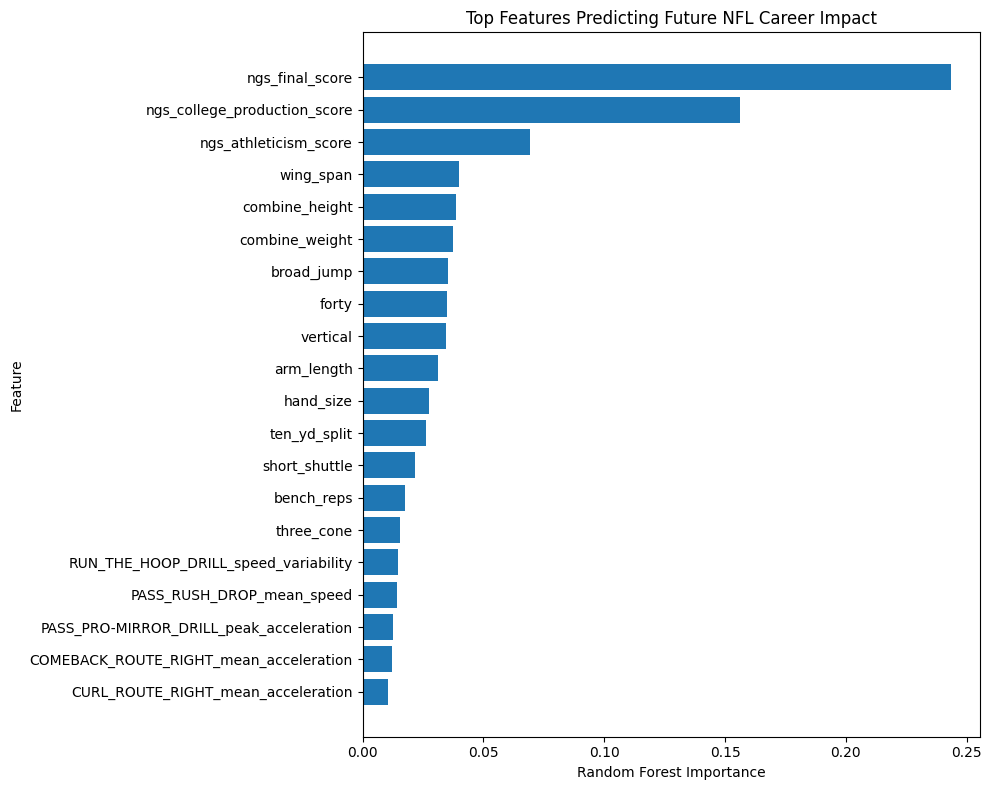

In [80]:
# Top Feature Importance


import matplotlib.pyplot as plt

top_plot = feature_importance.head(20).sort_values("importance")

plt.figure(figsize=(10, 8))
plt.barh(
    top_plot["feature"],
    top_plot["importance"]
)

plt.xlabel("Random Forest Importance")
plt.ylabel("Feature")
plt.title("Top Features Predicting Future NFL Career Impact")
plt.tight_layout()
plt.show()

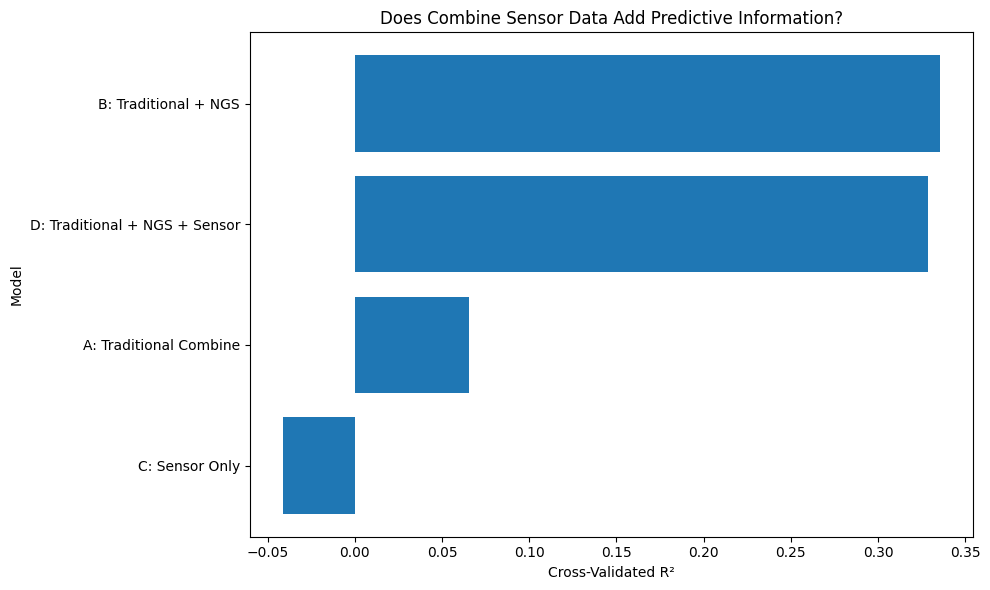

In [81]:
# Model Comparison


plot_df = final_results.sort_values("R2")

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["Model"],
    plot_df["R2"]
)

plt.xlabel("Cross-Validated R²")
plt.ylabel("Model")
plt.title("Does Combine Sensor Data Add Predictive Information?")
plt.tight_layout()
plt.show()

In [82]:
# Key Sensor Discoveries

sensor_discoveries = (
    drill_correlations
    .loc[top_sensor_features]
    .sort_values()
)

print("Most negative relationships:")
display(sensor_discoveries.head(10).to_frame("correlation"))

print("\nMost positive relationships:")
display(sensor_discoveries.tail(10).sort_values(
    ascending=False
).to_frame("correlation"))

Most negative relationships:


,correlation
END_ZONE_FADE_RIGHT_peak_acceleration,-0.440948
HOOK_ROUTE_RIGHT_range_y,-0.399491
END_ZONE_FADE_RIGHT_acceleration_variability,-0.388501
HOOK_ROUTE_RIGHT_mean_speed,-0.322466
SPEED_OUT_LEFT_range_y,-0.284563
SPEED_OUT_LEFT_speed_variability,-0.281134
LINE_peak_speed,-0.266377
END_ZONE_FADE_RIGHT_range_x,-0.265656
END_ZONE_FADE_RIGHT_peak_distance,-0.258630
END_ZONE_FADE_RIGHT_speed_variability,-0.226483



Most positive relationships:


,correlation
PASS_PRO_MIRROR_DRILL_range_x,0.348108
SHORT_ZONE_BREAKS_peak_speed,0.318108
PASS_PRO_MIRROR_DRILL_movement_efficiency,0.307602
SPEED_OUT_LEFT_range_x,0.303964
PASS_PRO_MIRROR_DRILL_speed_variability,0.280132
PASS_PRO-MIRROR_DRILL_peak_acceleration,0.275423
PASS_PRO-MIRROR_DRILL_mean_distance,0.274362
PASS_PRO-MIRROR_DRILL_peak_distance,0.274362
RUN_THE_HOOP_DRILL_speed_variability,0.264342
CORNER_ROUTE_mean_acceleration,0.258000


In [83]:

#  Final Results Table


final_summary = final_results.copy()

final_summary["R2"] = final_summary["R2"].round(4)
final_summary["R2_std"] = final_summary["R2_std"].round(4)
final_summary["MAE"] = final_summary["MAE"].round(4)
final_summary["MAE_std"] = final_summary["MAE_std"].round(4)

display(final_summary)

,Model,R2,R2_std,MAE,MAE_std
1,B: Traditional + NGS,0.3355,0.0484,0.1384,0.0059
3,D: Traditional + NGS + Sensor,0.3289,0.0530,0.1404,0.0068
0,A: Traditional Combine,0.0652,0.0192,0.1683,0.0106
2,C: Sensor Only,-0.0414,0.0729,0.1793,0.0123


In [84]:
# Robustness Target Without Awards


master["career_impact_ex_awards"] = (
    master["snaps_percentile"]
    + master["active_games_percentile"]
    + master["started_games_percentile"]
) / 3

drill_model_data["career_impact_ex_awards"] = (
    drill_model_data["snaps_percentile"]
    + drill_model_data["active_games_percentile"]
    + drill_model_data["started_games_percentile"]
) / 3

y_robust = drill_model_data["career_impact_ex_awards"]

print("Robustness target created.")
print(y_robust.describe())

Robustness target created.
count    510.000000
mean       0.502941
std        0.262976
min        0.108333
25%        0.243685
50%        0.503867
75%        0.741716
max        0.955208
Name: career_impact_ex_awards, dtype: float64


In [85]:
# Robustness Test


robust_metrics = evaluate_model(
    X_combined,
    y_robust
)

print("Combined model without award information:")
print(f"R²  : {robust_metrics['R2']:.4f}")
print(f"MAE : {robust_metrics['MAE']:.4f}")

Combined model without award information:
R²  : 0.3276
MAE : 0.1840


## Project Summary

In this project, I explored whether NFL Combine tracking data can help predict how successful a player may become in their NFL career.

I worked with four datasets: **Combine sensor tracking, traditional Combine results, player information, and career success data**. I cleaned and joined the data, created a career impact score, and built different movement features from the sensor data, such as **speed, acceleration, distance, movement range, and movement efficiency**.

I tested four models to compare:

* Traditional Combine data
* Traditional Combine + NGS scores
* Sensor data only
* Traditional Combine + NGS + Sensor data

The **Traditional + NGS model performed best**, with an R² of **0.3355**. Adding the sensor features did not improve the overall prediction, but the sensor analysis still found several interesting relationships between specific drill movements and future career success.

Overall, this project showed that **traditional Combine and NGS information already carries a lot of useful signal**, while sensor tracking can provide additional insights into how players move, even when it does not improve the final prediction.
